# Proyecto PRASS: Seguimiento al COVID-19

**Especialización en Analítica y Ciencia de Datos — Fundamentos de Ciencia de Datos**

Autor: Jabes Monroy

Este cuaderno desarrolla, de forma reproducible, el análisis del conjunto de datos de seguimiento del programa PRASS (Pruebas, Rastreo y Aislamiento Selectivo Sostenible). Se trabaja como entregable único: cada decisión metodológica se justifica de manera breve. Las funciones reutilizables se centralizan en el módulo `utils.py`, que este cuaderno importa.

**Estructura:** Parte I — observación y exploración del dato; Parte II — preprocesamiento.

## 1. Naturaleza de los datos

La base recoge el **seguimiento epidemiológico de casos COVID-19** realizado bajo el programa PRASS en Colombia. Cada registro resume, para una combinación de fuente, fecha, territorio (departamento y municipio) y entidad reportante, el número de casos y cuántos de ellos recibieron o no seguimiento. La granularidad es, por tanto, un dato agregado por grupo y no por individuo. La extracción tiene una fecha de corte única (25 de mayo de 2022).

**Fuente:** Portal de Datos Abiertos de Colombia (datos.gov.co), conjunto de datos identificado como `r6r5-w84k`. Archivo descargado de https://www.datos.gov.co/api/views/r6r5-w84k/rows.csv?accessType=DOWNLOAD

**Qué se espera observar.** Como instrumento de vigilancia, se anticipa que la mayoría de los grupos correspondan a pocos casos (distribución asimétrica), con una cobertura de seguimiento variable entre territorios y entidades. El interés analítico está en cuantificar esa cobertura, identificar brechas (grupos con alta proporción sin seguimiento) y comparar fuentes y entidades territoriales.

**Diccionario de variables (12).**

| Variable | Contenido |
|----------|-----------|
| `Fuente` | Origen del registro: `CONFIRMADOS`, `SOSPECHOSOS SIVIGILA` o `POBLACIÓN NO AFILIADA`. |
| `FechaRegistro` | Fecha de registro del caso (formato `MM/DD/AAAA`; la hora es constante). |
| `FechaRegistroSemana` | Semana epidemiológica del registro. |
| `Departamento` | Entidad territorial departamental, en formato `código DIVIPOLA - nombre`. |
| `Municipio` | Municipio, en formato `código DIVIPOLA - nombre`. |
| `EntidadRegistro` | Entidad (EPS, aseguradora o institución) que reporta el seguimiento. |
| `NumeroCasos` | Total de casos del grupo. |
| `NumeroCasosSinSeguimiento` | Casos del grupo sin seguimiento PRASS. |
| `NumeroCasosConSeguimiento` | Casos del grupo con seguimiento PRASS. |
| `PorcentajeCasosSinSeguimiento` | Proporción sin seguimiento (escala inconsistente; ver sección 10). |
| `PorcentajeCasosConSeguimiento` | Proporción con seguimiento (escala inconsistente; ver sección 10). |
| `FechaCorte` | Fecha de corte de la extracción (constante). |

A continuación se cargan los datos y se examina su estructura.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = utils.cargar_datos()
df.shape

(339646, 12)

La carga se realiza con `utils.cargar_datos`, que emplea el lector por defecto de pandas. Este respeta el entrecomillado de campos (norma RFC 4180), relevante porque algunos territorios contienen comas dentro del nombre, por ejemplo `"11001 - BOGOTÁ, D.C."`; al estar entrecomillados, dichas comas no fragmentan las columnas y no se produce desalineación. El conjunto tiene 339.646 registros y 12 variables.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 339646 entries, 0 to 339645
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   Fuente                         339646 non-null  str   
 1   FechaRegistro                  339646 non-null  str   
 2   FechaRegistroSemana            339646 non-null  int64 
 3   Departamento                   339646 non-null  str   
 4   Municipio                      339646 non-null  str   
 5   EntidadRegistro                339646 non-null  str   
 6   NumeroCasos                    339646 non-null  int64 
 7   NumeroCasosSinSeguimiento      339646 non-null  int64 
 8   NumeroCasosConSeguimiento      339646 non-null  int64 
 9   PorcentajeCasosSinSeguimiento  339646 non-null  str   
 10  PorcentajeCasosConSeguimiento  339646 non-null  object
 11  FechaCorte                     339646 non-null  str   
dtypes: int64(4), object(1), str(7)
memory usage: 31.1+ MB


In [5]:
df.head()

,Fuente,FechaRegistro,FechaRegistroSemana,Departamento,Municipio,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento,FechaCorte
0,CONFIRMADOS,07/03/2021 12:00:00 AM,26,41 - HUILA,41551 - PITALITO,MEDIMAS EPS SAS,1,0,1,0,10000000000000000000000,2022-05-25
1,CONFIRMADOS,05/18/2021 12:00:00 AM,20,94 - GUAINÍA,94001 - INÍRIDA,COOSALUD,9,0,9,0,10000000000000000000000,2022-05-25
2,CONFIRMADOS,05/19/2021 12:00:00 AM,20,25 - CUNDINAMARCA,25269 - FACATATIVÁ,E.P.S. SANITAS S.A.,26,1,25,384615384615384000000,9615384615384610000000,2022-05-25
3,CONFIRMADOS,01/07/2021 12:00:00 AM,1,47 - MAGDALENA,47001 - SANTA MARTA,POLICIA NACIONAL,15,0,15,0,10000000000000000000000,2022-05-25
4,CONFIRMADOS,05/02/2021 12:00:00 AM,18,68 - SANTANDER,68524 - PALMAS DEL SOCORRO,COMPARTA EPS-S,1,0,1,0,10000000000000000000000,2022-05-25


## 2. Estadísticos descriptivos

Se resume la posición y dispersión de las variables, distinguiendo numéricas y categóricas, como referencia para las secciones posteriores.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FechaRegistroSemana,339646.0,16.523595,12.721912,1.0,5.0,15.0,22.0,53.0
NumeroCasos,339646.0,10.400102,135.745747,1.0,1.0,2.0,4.0,31654.0
NumeroCasosSinSeguimiento,339646.0,0.583505,8.625612,0.0,0.0,0.0,0.0,2519.0
NumeroCasosConSeguimiento,339646.0,9.816597,131.540808,0.0,1.0,1.0,4.0,31654.0


In [7]:
df.describe(include='object').T

,count,unique,top,freq
Fuente,339646,3,CONFIRMADOS,300309
FechaRegistro,339646,428,06/28/2021 12:00:00 AM,7878
Departamento,339646,33,05 - ANTIOQUIA,40027
Municipio,339646,1121,"11001 - BOGOTÁ, D.C.",7032
EntidadRegistro,339646,68,NUEVA EPS S.A.,54641
PorcentajeCasosSinSeguimiento,339646,2625,0,295586
PorcentajeCasosConSeguimiento,339646,2832,10000000000000000000000,284468
FechaCorte,339646,1,2022-05-25,339646


Las variables de conteo muestran medias muy superiores a sus medianas, primer indicio de asimetría positiva. En las categóricas, la columna con valor más frecuente y su frecuencia (`top`, `freq`) anticipan los desbalances que se detallan en la sección 5.

## 3. Identificación de datos faltantes (missing data)

Se cuantifica la ausencia de información por variable, en valor absoluto y porcentaje, como paso previo a cualquier decisión de imputación.

In [8]:
faltantes = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct': (df.isna().mean() * 100).round(2),
})
faltantes

,nulos,pct
Fuente,0,0.0
FechaRegistro,0,0.0
FechaRegistroSemana,0,0.0
Departamento,0,0.0
Municipio,0,0.0
EntidadRegistro,0,0.0
NumeroCasos,0,0.0
NumeroCasosSinSeguimiento,0,0.0
NumeroCasosConSeguimiento,0,0.0
PorcentajeCasosSinSeguimiento,0,0.0


No se observan valores faltantes en ninguna variable. En consecuencia, no se requiere imputación y el conjunto está completo en su forma cruda.

## 4. Registros duplicados

Se verifica la existencia de filas completamente repetidas, que podrían inflar los conteos o introducir sesgos en análisis posteriores.

In [9]:
n_dup = int(df.duplicated().sum())
print(f'Filas duplicadas (todas las columnas): {n_dup} ({n_dup / len(df):.2%})')
df[df.duplicated(keep=False)].head()

Filas duplicadas (todas las columnas): 0 (0.00%)


,Fuente,FechaRegistro,FechaRegistroSemana,Departamento,Municipio,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento,FechaCorte


Dado que cada fila es un agregado por fuente, fecha, territorio y entidad, un duplicado exacto implicaría un registro repetido. Se reporta su número para decidir, en la fase de limpieza, si corresponde consolidarlos.

## 5. Unicidad de valores y categorías distintas

Se examina la cardinalidad de cada variable y la distribución de frecuencias de las principales variables categóricas, para comprender su granularidad y posibles desbalances.

In [10]:
df.nunique().sort_values()

FechaCorte                          1
Fuente                              3
Departamento                       33
FechaRegistroSemana                53
EntidadRegistro                    68
NumeroCasosSinSeguimiento         243
FechaRegistro                     428
NumeroCasosConSeguimiento        1059
NumeroCasos                      1085
Municipio                        1121
PorcentajeCasosSinSeguimiento    2625
PorcentajeCasosConSeguimiento    2832
dtype: int64

In [11]:
for c in ['Fuente', 'Departamento', 'EntidadRegistro']:
    print(f'{c}: {df[c].nunique()} categorías distintas')

df['Fuente'].value_counts()

Fuente: 3 categorías distintas
Departamento: 33 categorías distintas
EntidadRegistro: 68 categorías distintas


Fuente
CONFIRMADOS              300309
SOSPECHOSOS SIVIGILA      32608
POBLACIÓN NO AFILIADA      6729
Name: count, dtype: int64

In [12]:
df['Departamento'].value_counts().head(10)

Departamento
05 - ANTIOQUIA             40027
25 - CUNDINAMARCA          38753
76 - VALLE DEL CAUCA       27680
68 - SANTANDER             20469
15 - BOYACÁ                19204
08 - ATLÁNTICO             19010
52 - NARIÑO                13118
73 - TOLIMA                11554
54 - NORTE DE SANTANDER    10873
41 - HUILA                 10767
Name: count, dtype: int64

La variable `Fuente` presenta tres categorías, con predominio de los casos confirmados. `Departamento` agrupa 33 entidades territoriales y `Municipio` supera el millar de valores. Tanto `Departamento` como `Municipio` codifican conjuntamente el código DIVIPOLA y el nombre en un único campo (formato `código - NOMBRE`), lo que sugiere separarlos en la fase de limpieza.

## 6. Inconsistencias en variables de texto

Antes de tratar las categóricas como factores, se revisan irregularidades tipográficas (espacios al borde y espacios dobles internos) que harían que una misma categoría se cuente como varias.

In [13]:
cat = ['Fuente', 'Departamento', 'Municipio', 'EntidadRegistro']
reporte = []
for c in cat:
    s = df[c].astype(str)
    norm = s.str.strip().str.replace(r'\s+', ' ', regex=True)
    reporte.append({
        'variable': c,
        'espacios_borde': int((s != s.str.strip()).sum()),
        'espacios_dobles': int(s.str.contains(r'  ', regex=False).sum()),
        'unicos': s.nunique(),
        'unicos_norm': norm.nunique(),
    })
pd.DataFrame(reporte)

,variable,espacios_borde,espacios_dobles,unicos,unicos_norm
0,Fuente,0,0,3,3
1,Departamento,0,0,33,33
2,Municipio,0,0,1121,1121
3,EntidadRegistro,0,58396,68,68


Se detectan espacios dobles internos en `EntidadRegistro` (por ejemplo, `E.P.S. SANITAS  S.A.`). Cuando `unicos` y `unicos_norm` coinciden, la normalización no fusiona categorías distintas; aun así, conviene estandarizar los espacios en la limpieza para asegurar agrupaciones consistentes.

## 7. Variables con desviación estándar igual a cero

Una variable constante (desviación estándar nula o un único valor) no aporta información discriminante y es candidata a ser descartada.

In [14]:
constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print('Columnas constantes:', constantes)
df.select_dtypes('number').std(numeric_only=True)

Columnas constantes: ['FechaCorte']


FechaRegistroSemana           12.721912
NumeroCasos                  135.745747
NumeroCasosSinSeguimiento      8.625612
NumeroCasosConSeguimiento    131.540808
dtype: float64

La variable `FechaCorte` es constante (`2022-05-25`): corresponde a la fecha única de extracción del reporte y no varía entre registros, por lo que no aporta información y se propone eliminarla. Ninguna variable numérica de conteo presenta desviación estándar nula.

## 8. Identificación de valores atípicos (outliers)

Se analizan las variables de conteo mediante el método del rango intercuartílico (IQR), visualizado con diagramas de caja. Se consideran atípicos los valores fuera del intervalo [Q1 - 1.5·IQR, Q3 + 1.5·IQR].

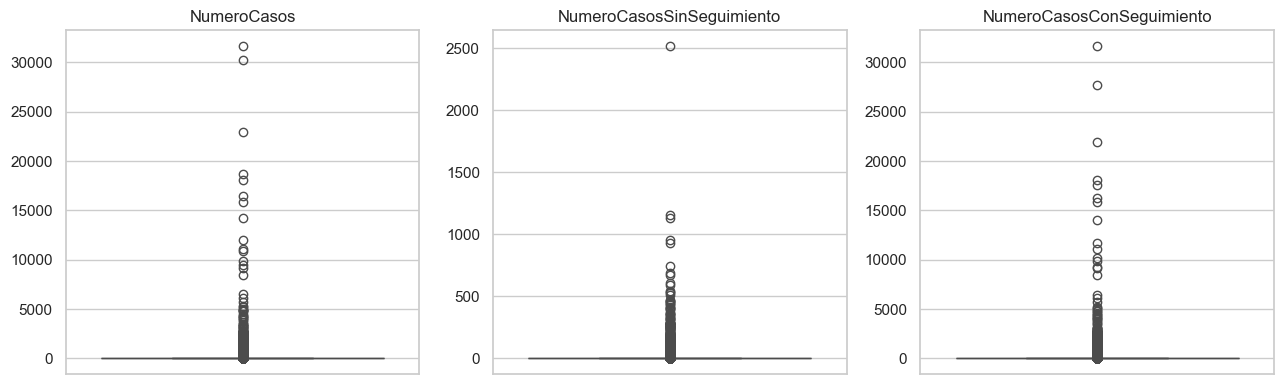

In [15]:
num = ['NumeroCasos', 'NumeroCasosSinSeguimiento', 'NumeroCasosConSeguimiento']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, num):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [16]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((s < bajo) | (s > alto)).sum())
    return {'Q1': q1, 'Q3': q3, 'max': s.max(), 'outliers': n, 'pct': round(n / len(s) * 100, 2)}

pd.DataFrame({c: iqr_outliers(df[c]) for c in num}).T

,Q1,Q3,max,outliers,pct
NumeroCasos,1.0,4.0,31654.0,46532.0,13.70
NumeroCasosSinSeguimiento,0.0,0.0,2519.0,44060.0,12.97
NumeroCasosConSeguimiento,1.0,4.0,31654.0,43767.0,12.89


Cerca del 13 % de los registros se clasifican como atípicos por IQR. No obstante, la mediana de casos es muy baja (entre 1 y 2) y el máximo alcanza 31.654, lo que evidencia una distribución fuertemente asimétrica y de cola larga, propia de datos de conteo. Por tanto, estos valores no constituyen errores de captura sino la naturaleza sesgada del fenómeno; se documentan, pero no se eliminan sin un criterio adicional.

## 9. Coherencia interna de los conteos

Se valida una identidad que el dato debe cumplir por construcción: el total de casos debe igualar la suma de los casos con y sin seguimiento.

In [17]:
suma = df['NumeroCasosConSeguimiento'] + df['NumeroCasosSinSeguimiento']
incoherentes = int((suma != df['NumeroCasos']).sum())
print(f'Registros donde Con + Sin != Total: {incoherentes} ({incoherentes / len(df):.2%})')

Registros donde Con + Sin != Total: 0 (0.00%)


La identidad `NumeroCasos = ConSeguimiento + SinSeguimiento` se cumple en la totalidad de los registros. Esto respalda la integridad de las variables de conteo y justifica recalcular los porcentajes a partir de ellas (sección 10).

## 10. Calidad de las variables de porcentaje

Se inspeccionan las columnas de porcentaje, reportadas en una escala inconsistente.

In [18]:
df[['NumeroCasos', 'NumeroCasosConSeguimiento',
    'PorcentajeCasosSinSeguimiento', 'PorcentajeCasosConSeguimiento']].head()

,NumeroCasos,NumeroCasosConSeguimiento,PorcentajeCasosSinSeguimiento,PorcentajeCasosConSeguimiento
0,1,1,0,10000000000000000000000
1,9,9,0,10000000000000000000000
2,26,25,384615384615384000000,9615384615384610000000
3,15,15,0,10000000000000000000000
4,1,1,0,10000000000000000000000


In [19]:
# Recálculo del porcentaje a partir de los conteos
pct_recalc = (df['NumeroCasosConSeguimiento'] / df['NumeroCasos'] * 100)
pct_recalc.describe()

count    339646.000000
mean         91.949712
std          25.150958
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
dtype: float64

Las columnas `PorcentajeCasos*` están corruptas: el valor 100 % aparece codificado como `1e22` y, en otros registros, como decimales, por una pérdida inconsistente del separador decimal. Dado que las variables de conteo son consistentes (sección 9), se decide **no utilizar dichas columnas** y recalcular la cobertura directamente como `NumeroCasosConSeguimiento / NumeroCasos`. El recálculo arroja un rango coherente [0, 100].

## 11. Test de Little (MCAR)

El test de Little evalúa si los datos faltantes siguen un mecanismo completamente aleatorio (MCAR). Su aplicación exige la presencia de valores ausentes. Como se estableció en la sección 3, el conjunto no presenta datos faltantes; por consiguiente, el test **no es aplicable** en esta etapa. De introducirse faltantes tras la limpieza (por ejemplo, al invalidar registros inconsistentes), se retomará su evaluación.

## 12. Síntesis de la exploración

Hallazgos de la Parte I:

- El conjunto tiene 339.646 registros y 12 variables, sin valores faltantes ni duplicados.
- No existe desalineación de columnas: las comas internas están entrecomilladas.
- La identidad de conteos (total = con + sin seguimiento) se cumple en todos los registros.
- `FechaCorte` es constante y será eliminada por no aportar información.
- `Departamento` y `Municipio` combinan código y nombre; conviene separarlos.
- `FechaRegistro` requiere conversión a tipo fecha.
- `EntidadRegistro` presenta espacios dobles que conviene estandarizar.
- Las variables de porcentaje están corruptas y se recalcularán desde los conteos.
- La distribución de casos es asimétrica; los atípicos reflejan el fenómeno, no errores.

Estos hallazgos definen las transformaciones de la Parte II.

# Parte II — Preprocesamiento

Se aplican las transformaciones derivadas de la exploración. Las funciones se centralizan en `utils.py` y se invocan paso a paso, justificando cada decisión. Se parte de una copia del dato crudo para preservar el original.

### 13. Tipado de la fecha de registro

`FechaRegistro` llega como texto con una hora constante (medianoche). Se convierte a tipo fecha para habilitar análisis temporales; la componente horaria, sin información, se descarta.

In [20]:
df_prep = df.copy()
df_prep['FechaRegistro'] = utils.parsear_fecha(df_prep['FechaRegistro'])
df_prep['FechaRegistro'].describe()

count                        339646
mean     2021-06-28 05:06:06.671181
min             2020-05-04 00:00:00
25%             2021-03-16 00:00:00
50%             2021-05-21 00:00:00
75%             2021-09-28 00:00:00
max             2022-05-18 00:00:00
Name: FechaRegistro, dtype: object

### 14. Separación de código y nombre territorial

`Departamento` y `Municipio` combinan el código DIVIPOLA y el nombre. Se separan en columnas `...Codigo` y `...Nombre`, lo que facilita agrupaciones y futuros cruces con otras fuentes.

In [21]:
for col in ['Departamento', 'Municipio']:
    cn = utils.separar_codigo_nombre(df_prep[col])
    df_prep[col + 'Codigo'] = cn['codigo']
    df_prep[col + 'Nombre'] = cn['nombre']
df_prep[['DepartamentoCodigo', 'DepartamentoNombre',
         'MunicipioCodigo', 'MunicipioNombre']].head()

,DepartamentoCodigo,DepartamentoNombre,MunicipioCodigo,MunicipioNombre
0,41,HUILA,41551,PITALITO
1,94,GUAINÍA,94001,INÍRIDA
2,25,CUNDINAMARCA,25269,FACATATIVÁ
3,47,MAGDALENA,47001,SANTA MARTA
4,68,SANTANDER,68524,PALMAS DEL SOCORRO


### 15. Estandarización de texto

Se normalizan los espacios de `EntidadRegistro` (bordes y dobles internos) para asegurar agrupaciones consistentes.

In [22]:
df_prep['EntidadRegistro'] = utils.estandarizar_texto(df_prep['EntidadRegistro'])
print('Filas con espacios dobles tras estandarizar:',
      int(df_prep['EntidadRegistro'].str.contains(r'  ', regex=False).sum()))

Filas con espacios dobles tras estandarizar: 0


### 16. Recálculo de la cobertura de seguimiento

En reemplazo de las columnas de porcentaje corruptas, se calcula la cobertura (%) a partir de los conteos, ya validados como coherentes.

In [23]:
df_prep = utils.agregar_cobertura(df_prep)
df_prep[['NumeroCasos', 'NumeroCasosConSeguimiento',
         'CoberturaConSeguimiento', 'CoberturaSinSeguimiento']].head()

,NumeroCasos,NumeroCasosConSeguimiento,CoberturaConSeguimiento,CoberturaSinSeguimiento
0,1,1,100.00,0.00
1,9,9,100.00,0.00
2,26,25,96.15,3.85
3,15,15,100.00,0.00
4,1,1,100.00,0.00


### 17. Eliminación de columnas constantes o corruptas

Se descartan `FechaCorte` (constante), las dos columnas de porcentaje corruptas y los campos territoriales originales, ya sustituidos por sus versiones código/nombre.

In [24]:
df_prep = df_prep.drop(columns=[
    'FechaCorte', 'PorcentajeCasosSinSeguimiento', 'PorcentajeCasosConSeguimiento',
    'Departamento', 'Municipio',
])
df_prep.info()

<class 'pandas.DataFrame'>
RangeIndex: 339646 entries, 0 to 339645
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Fuente                     339646 non-null  str           
 1   FechaRegistro              339646 non-null  datetime64[us]
 2   FechaRegistroSemana        339646 non-null  int64         
 3   EntidadRegistro            339646 non-null  str           
 4   NumeroCasos                339646 non-null  int64         
 5   NumeroCasosSinSeguimiento  339646 non-null  int64         
 6   NumeroCasosConSeguimiento  339646 non-null  int64         
 7   DepartamentoCodigo         339646 non-null  str           
 8   DepartamentoNombre         339646 non-null  str           
 9   MunicipioCodigo            339646 non-null  str           
 10  MunicipioNombre            339646 non-null  str           
 11  CoberturaConSeguimiento    339646 non-null  float64       
 12 

### 18. Diagnóstico y conversión de tipos

Se revisa, para cada columna no numérica, si su contenido es convertible a número, distinguiendo numéricas mal tipadas de identificadores. Luego se asigna el tipo adecuado: `category` para las variables de baja cardinalidad y categoría ordinal para la semana epidemiológica.

In [25]:
utils.diagnosticar_tipos(df_prep)

,columna,dtype,convertible_a_numerico,es_identificador
0,Fuente,str,False,False
1,EntidadRegistro,str,False,False
2,DepartamentoCodigo,str,True,True
3,DepartamentoNombre,str,False,False
4,MunicipioCodigo,str,True,True
5,MunicipioNombre,str,False,False


Las únicas columnas convertibles a número que **no** deben convertirse son los códigos DIVIPOLA (`DepartamentoCodigo`, `MunicipioCodigo`): son identificadores y perderían los ceros a la izquierda. El resto de variables de texto son categóricas legítimas. En consecuencia, se tipifican como `category` (y la semana epidemiológica como categoría ordinal), sin forzar conversiones numéricas.

In [26]:
df_prep = utils.tipar_columnas(df_prep)
df_prep.dtypes

Fuente                             category
FechaRegistro                datetime64[us]
FechaRegistroSemana                category
EntidadRegistro                    category
NumeroCasos                           int64
NumeroCasosSinSeguimiento             int64
NumeroCasosConSeguimiento             int64
DepartamentoCodigo                 category
DepartamentoNombre                 category
MunicipioCodigo                    category
MunicipioNombre                    category
CoberturaConSeguimiento             float64
CoberturaSinSeguimiento             float64
dtype: object

### 19. Resultado del preprocesamiento

El DataFrame depurado `df_prep` queda tipado, con territorio descompuesto, texto estandarizado, cobertura recalculada y tipos asignados (`category` y categoría ordinal). Sirve de base para la siguiente etapa (EDA). La orquestación equivalente está disponible en `utils.preprocesar`.

In [27]:
df_prep.head()

,Fuente,FechaRegistro,FechaRegistroSemana,EntidadRegistro,NumeroCasos,NumeroCasosSinSeguimiento,NumeroCasosConSeguimiento,DepartamentoCodigo,DepartamentoNombre,MunicipioCodigo,MunicipioNombre,CoberturaConSeguimiento,CoberturaSinSeguimiento
0,CONFIRMADOS,2021-07-03,26,MEDIMAS EPS SAS,1,0,1,41,HUILA,41551,PITALITO,100.00,0.00
1,CONFIRMADOS,2021-05-18,20,COOSALUD,9,0,9,94,GUAINÍA,94001,INÍRIDA,100.00,0.00
2,CONFIRMADOS,2021-05-19,20,E.P.S. SANITAS S.A.,26,1,25,25,CUNDINAMARCA,25269,FACATATIVÁ,96.15,3.85
3,CONFIRMADOS,2021-01-07,1,POLICIA NACIONAL,15,0,15,47,MAGDALENA,47001,SANTA MARTA,100.00,0.00
4,CONFIRMADOS,2021-05-02,18,COMPARTA EPS-S,1,0,1,68,SANTANDER,68524,PALMAS DEL SOCORRO,100.00,0.00


# Parte III — Análisis exploratorio (EDA)

Sobre el dato depurado `df_prep` se exploran las distribuciones y la métrica central del estudio: la cobertura de seguimiento. El EDA se desarrolla por bloques; este primero aborda distribuciones y cobertura global.

### 20. Distribución de las variables de conteo

Por la fuerte asimetría detectada en la Parte I, las variables de conteo se visualizan en escala logarítmica (`log1p`), que comprime la cola larga y revela la forma de la distribución.

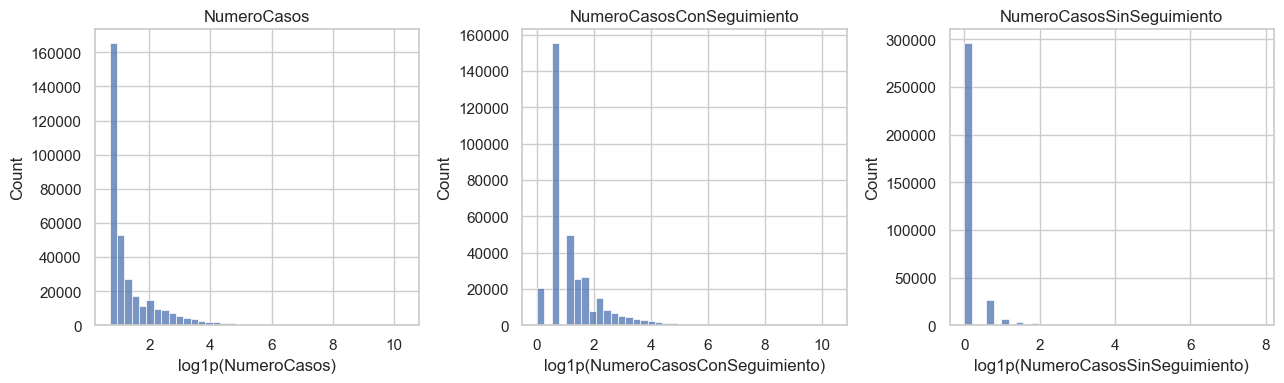

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, c in zip(axes, ['NumeroCasos', 'NumeroCasosConSeguimiento', 'NumeroCasosSinSeguimiento']):
    sns.histplot(np.log1p(df_prep[c]), bins=40, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('log1p(' + c + ')')
plt.tight_layout()
plt.show()

La mayoría de los grupos concentra pocos casos: las distribuciones decaen rápidamente incluso en escala logarítmica. `NumeroCasosSinSeguimiento` se acumula en cero, coherente con una cobertura alta en gran parte de los registros.

### 21. Distribución de la cobertura de seguimiento

Se examina la distribución de `CoberturaConSeguimiento` (%), la variable de interés recalculada desde los conteos.

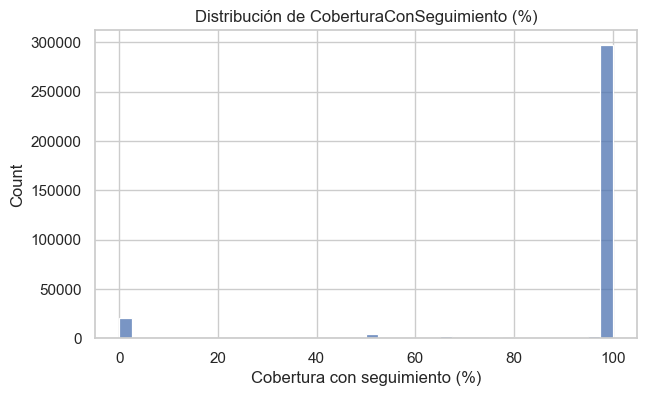

count    339646.000000
mean         91.949721
std          25.150957
min           0.000000
25%         100.000000
50%         100.000000
75%         100.000000
max         100.000000
Name: CoberturaConSeguimiento, dtype: float64

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_prep['CoberturaConSeguimiento'], bins=40, ax=ax)
ax.set_title('Distribución de CoberturaConSeguimiento (%)')
ax.set_xlabel('Cobertura con seguimiento (%)')
plt.show()
df_prep['CoberturaConSeguimiento'].describe()

La cobertura se concentra fuertemente en el 100 %: en la mayoría de los grupos todos los casos reciben seguimiento. Existe, no obstante, una fracción de registros con cobertura parcial o nula que constituye el foco de interés (brechas).

### 22. Cobertura global ponderada por casos

El promedio simple de la cobertura por fila sobrerrepresenta a los grupos pequeños. La medida correcta de la cobertura real del sistema pondera por el número de casos: `sum(ConSeguimiento) / sum(NumeroCasos)`.

In [30]:
casos = df_prep['NumeroCasos'].sum()
con = df_prep['NumeroCasosConSeguimiento'].sum()
glob_pond = con / casos * 100
glob_simple = df_prep['CoberturaConSeguimiento'].mean()
print(f'Casos totales: {casos:,}')
print(f'Cobertura global ponderada por casos: {glob_pond:.2f}%')
print(f'Promedio simple de filas:            {glob_simple:.2f}%')

Casos totales: 3,532,353
Cobertura global ponderada por casos: 94.39%
Promedio simple de filas:            91.95%


La cobertura global ponderada difiere del promedio simple de filas, lo que confirma que esta última está sesgada por la abundancia de grupos pequeños. En adelante, las comparaciones por fuente, territorio y entidad usarán la versión ponderada por casos.

### 23. Análisis univariado de variables categóricas

Se describe la composición de las principales categóricas. `Fuente`, con tres categorías, se resume en un gráfico de torta; `Departamento` y `EntidadRegistro`, de mayor cardinalidad, mediante barras de las categorías más frecuentes.

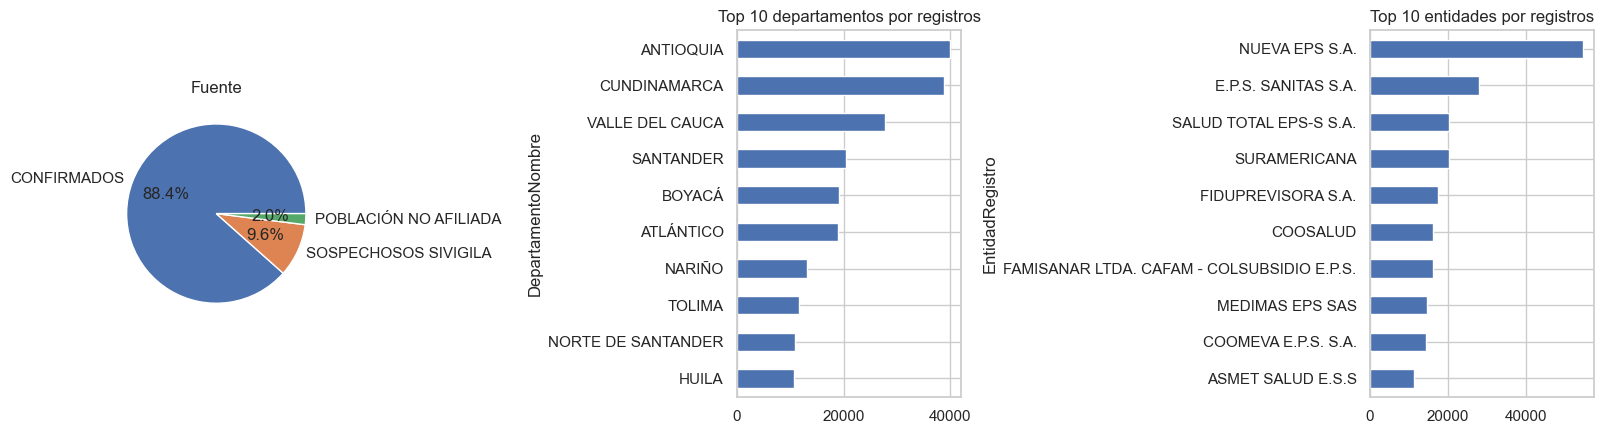

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
df_prep['Fuente'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], ylabel='')
axes[0].set_title('Fuente')
df_prep['DepartamentoNombre'].value_counts().head(10).plot.barh(ax=axes[1])
axes[1].set_title('Top 10 departamentos por registros')
axes[1].invert_yaxis()
df_prep['EntidadRegistro'].value_counts().head(10).plot.barh(ax=axes[2])
axes[2].set_title('Top 10 entidades por registros')
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

Predominan los casos `CONFIRMADOS`. Los registros se concentran en los departamentos más poblados (Antioquia, Cundinamarca, Valle) y en unas pocas entidades de gran tamaño (NUEVA EPS, Sanitas), lo que anticipa desbalances a considerar en los análisis comparativos.

### 24. Estimación de densidad (KDE)

La densidad por núcleo (KDE) complementa los histogramas mostrando la forma suavizada de la distribución de la cobertura y de los conteos (en escala logarítmica).

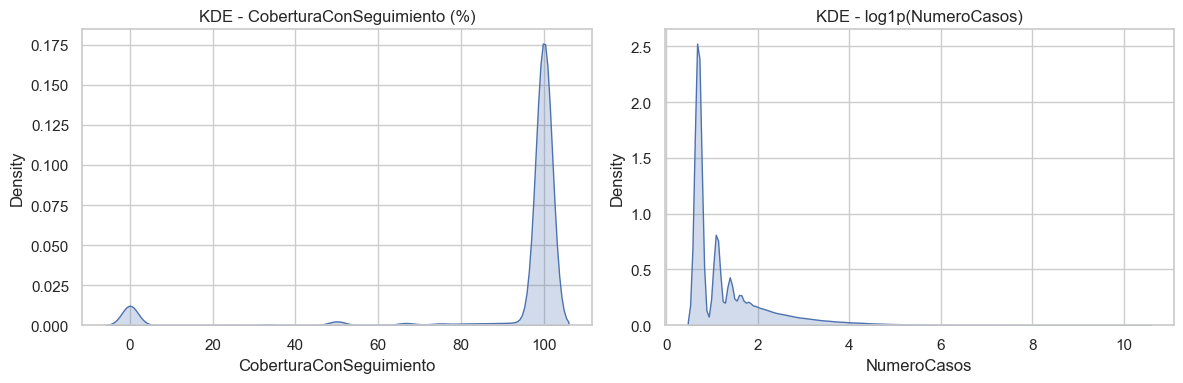

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(df_prep['CoberturaConSeguimiento'], fill=True, ax=axes[0])
axes[0].set_title('KDE - CoberturaConSeguimiento (%)')
sns.kdeplot(np.log1p(df_prep['NumeroCasos']), fill=True, ax=axes[1])
axes[1].set_title('KDE - log1p(NumeroCasos)')
plt.tight_layout()
plt.show()

La densidad confirma la fuerte concentración de la cobertura cerca del 100 % y la asimetría positiva de los conteos, que persiste aun en escala logarítmica.

## Bloque 3 — Análisis bivariado: cobertura por categoría

Se relaciona la variable objetivo (cobertura de seguimiento) con las principales categóricas. En todos los casos la cobertura se calcula **ponderada por casos** (`utils.cobertura_ponderada`), que refleja la cobertura real del sistema y no sobrerrepresenta a los grupos pequeños.

### 25. Cobertura por fuente

Comparación de la cobertura entre los tres orígenes de registro.

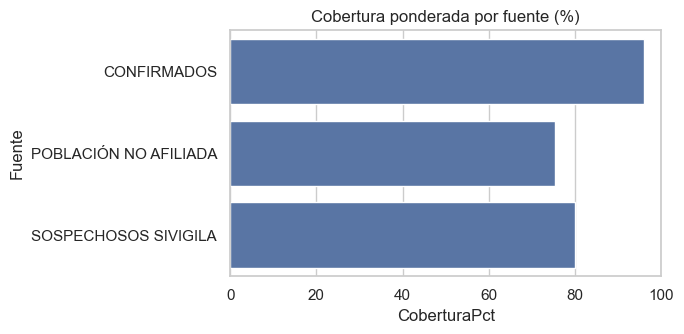

,Fuente,casos,con,CoberturaPct
0,POBLACIÓN NO AFILIADA,38311,28907,75.45
1,SOSPECHOSOS SIVIGILA,302180,241526,79.93
2,CONFIRMADOS,3191862,3063735,95.99


In [33]:
cob_fuente = utils.cobertura_ponderada(df_prep, 'Fuente')
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=cob_fuente, x='CoberturaPct', y='Fuente', ax=ax)
ax.set_title('Cobertura ponderada por fuente (%)')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()
cob_fuente

La cobertura difiere según el origen del registro, lo que sugiere que el mecanismo de captación (confirmados, sospechosos o población no afiliada) condiciona el seguimiento.

### 26. Cobertura por departamento

Se ordenan los departamentos por cobertura para identificar las mayores brechas (extremos inferior y superior).

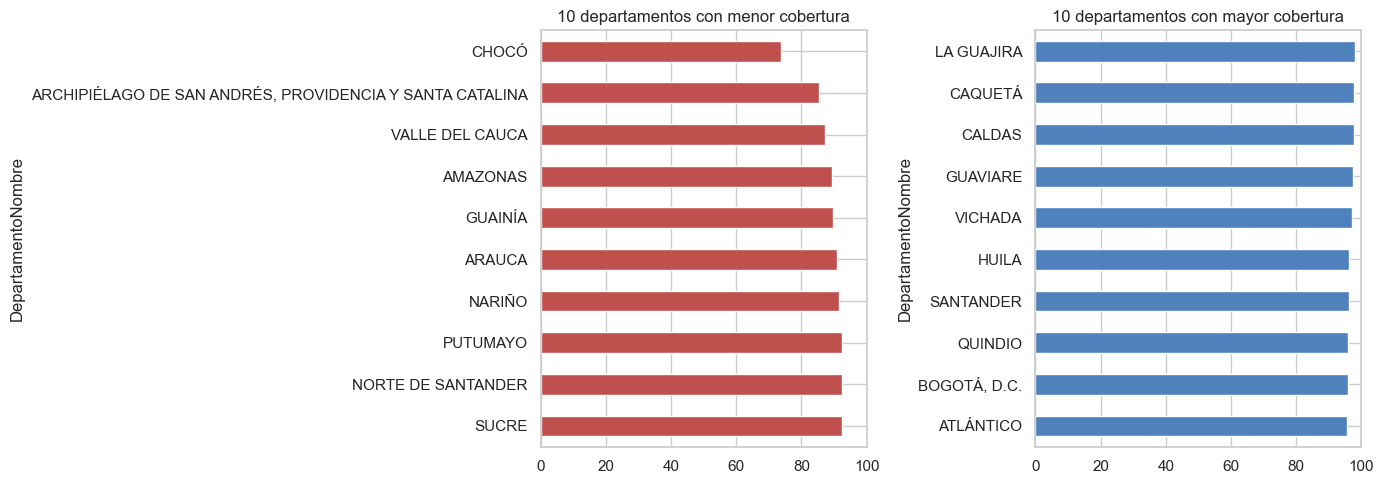

In [34]:
cob_dep = utils.cobertura_ponderada(df_prep, 'DepartamentoNombre')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cob_dep.head(10).plot.barh(x='DepartamentoNombre', y='CoberturaPct', ax=axes[0], legend=False, color='#c0504d')
axes[0].set_title('10 departamentos con menor cobertura')
axes[0].set_xlim(0, 100)
axes[0].invert_yaxis()
cob_dep.tail(10).plot.barh(x='DepartamentoNombre', y='CoberturaPct', ax=axes[1], legend=False, color='#4f81bd')
axes[1].set_title('10 departamentos con mayor cobertura')
axes[1].set_xlim(0, 100)
plt.tight_layout()
plt.show()

Existe heterogeneidad territorial: los departamentos del extremo inferior concentran las brechas de seguimiento y serían prioritarios para intervención, frente a los de cobertura cercana al 100 %.

### 27. Cobertura por entidad reportante

Para evitar el ruido de entidades con muy pocos casos, se exigen al menos 1.000 casos. Se muestran las diez entidades con menor cobertura.

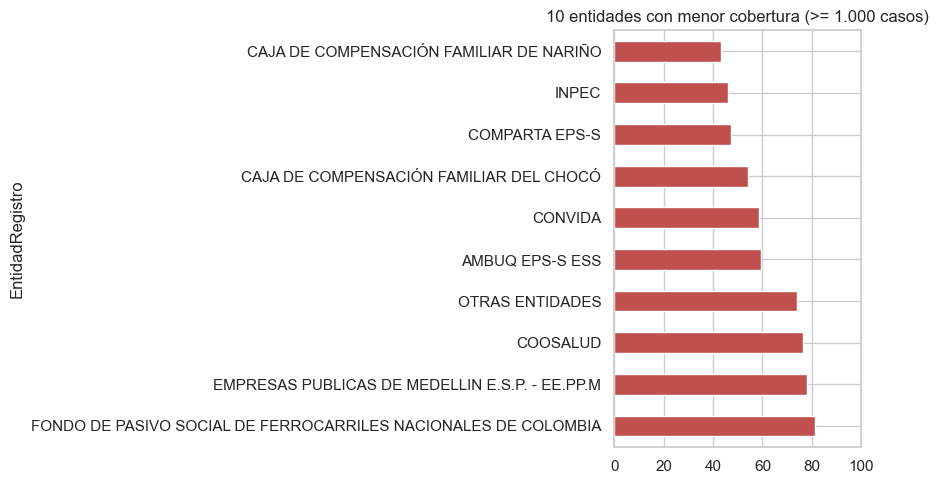

,EntidadRegistro,casos,con,CoberturaPct
0,CAJA DE COMPENSACIÓN FAMILIAR DE NARIÑO,3545,1531,43.19
1,INPEC,4103,1893,46.14
2,COMPARTA EPS-S,27507,12975,47.17
3,CAJA DE COMPENSACIÓN FAMILIAR DEL CHOCÓ,3431,1863,54.30
4,CONVIDA,17117,10053,58.73
5,AMBUQ EPS-S ESS,4878,2895,59.35
6,OTRAS ENTIDADES,39195,29007,74.01
7,COOSALUD,94775,72458,76.45
8,EMPRESAS PUBLICAS DE MEDELLIN E.S.P. - EE.PP.M,1018,793,77.90
9,FONDO DE PASIVO SOCIAL DE FERROCARRILES NACION...,2962,2407,81.26


In [35]:
cob_ent = utils.cobertura_ponderada(df_prep, 'EntidadRegistro', min_casos=1000)
fig, ax = plt.subplots(figsize=(9, 5))
cob_ent.head(10).plot.barh(x='EntidadRegistro', y='CoberturaPct', ax=ax, legend=False, color='#c0504d')
ax.set_title('10 entidades con menor cobertura (>= 1.000 casos)')
ax.set_xlim(0, 100)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
cob_ent.head(10)

La cobertura también varía entre entidades reportantes con volumen comparable, lo que apunta a diferencias en la gestión del seguimiento más allá del territorio.

## Bloque 4 — Análisis bivariado: variables numéricas

Se estudian las relaciones entre las variables numéricas y con la variable objetivo (`CoberturaConSeguimiento`). Conviene advertir que estas variables son **dependientes por construcción**: la cobertura se deriva de los conteos y `CoberturaSinSeguimiento` es el complemento exacto de la cobertura con seguimiento. Por ello, varias correlaciones son altas por definición y se interpretan con cautela. Se incorpora la semana epidemiológica como variable ordinal para explorar una posible tendencia temporal.

### 28. Matriz de correlación (heatmap)

Correlación de Pearson entre los conteos, la cobertura y la semana.

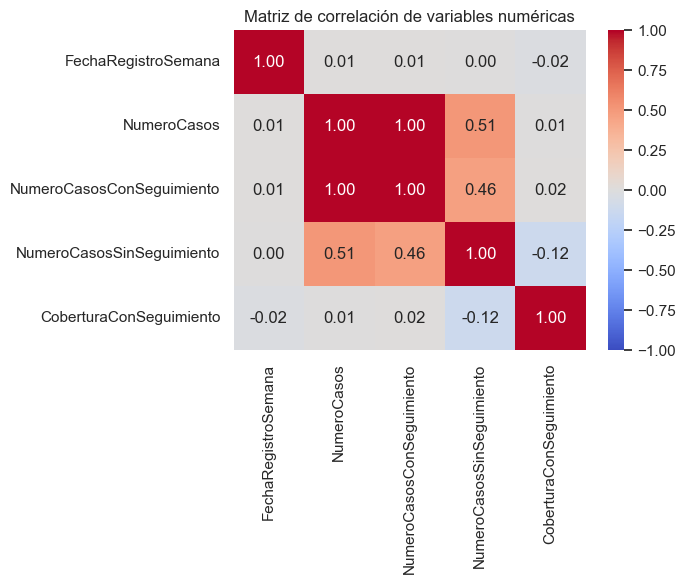

In [36]:
num = df_prep[['FechaRegistroSemana', 'NumeroCasos', 'NumeroCasosConSeguimiento',
               'NumeroCasosSinSeguimiento', 'CoberturaConSeguimiento']].copy()
num['FechaRegistroSemana'] = num['FechaRegistroSemana'].astype(int)
corr = num.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación de variables numéricas')
plt.tight_layout()
plt.show()

`NumeroCasos` y `NumeroCasosConSeguimiento` están casi perfectamente correlacionados, reflejo de la identidad estructural (la mayoría de los casos reciben seguimiento). La semana muestra una correlación débil con el resto, lo que sugiere ausencia de una tendencia temporal marcada.

### 29. Correlación con la variable objetivo

Se aísla la correlación de cada variable con `CoberturaConSeguimiento`.

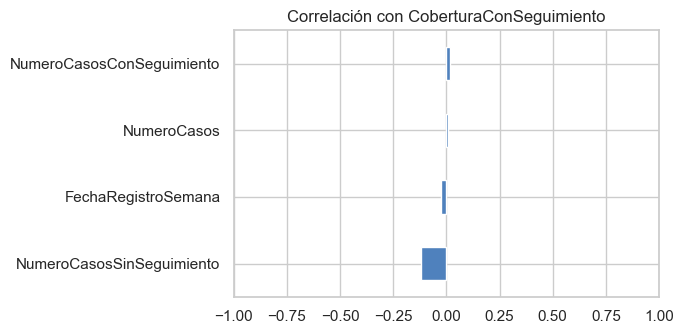

NumeroCasosSinSeguimiento   -0.120795
FechaRegistroSemana         -0.022888
NumeroCasos                  0.007432
NumeroCasosConSeguimiento    0.015590
Name: CoberturaConSeguimiento, dtype: float64

In [37]:
objetivo = corr['CoberturaConSeguimiento'].drop('CoberturaConSeguimiento').sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
objetivo.plot.barh(ax=ax, color='#4f81bd')
ax.set_title('Correlación con CoberturaConSeguimiento')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()
objetivo

Las correlaciones lineales de la cobertura con las variables de conteo son **débiles** (todas por debajo de 0,13 en valor absoluto). La más apreciable es la negativa con `NumeroCasosSinSeguimiento` (−0,12), lógica: a más casos sin seguimiento, menor cobertura. El tamaño del grupo (`NumeroCasos`, +0,01) y la semana (−0,02) no muestran relación lineal relevante. La razón es que la cobertura **satura en 100 %** en la mayoría de los grupos, lo que limita la correlación de Pearson; la relación real es no lineal y se aprecia mejor en los scatterplots de la sección 30.

### 30. Scatterplots

Para visualizar relaciones sin saturar el gráfico (339.646 puntos), se usa una muestra aleatoria de 5.000 registros y escala logarítmica en los conteos.

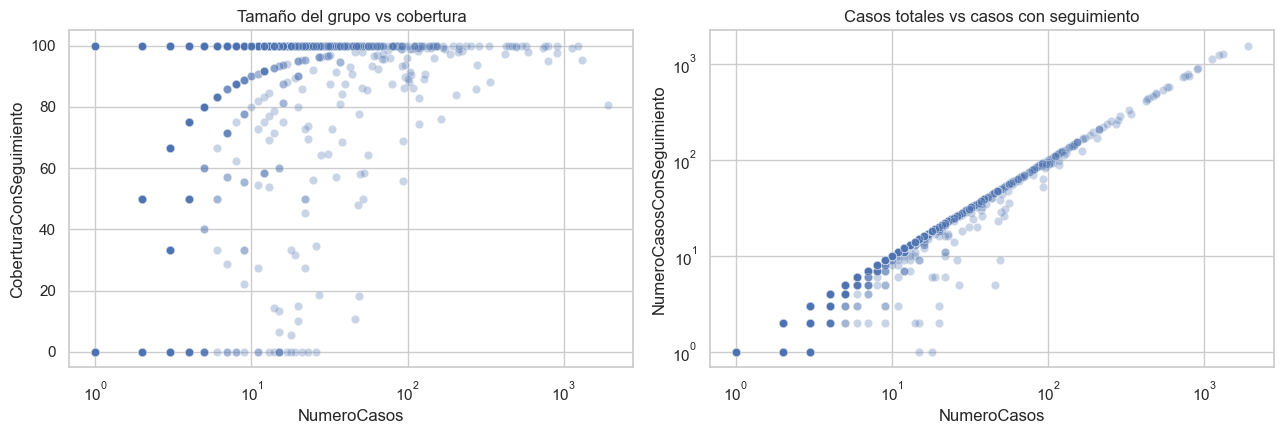

In [38]:
muestra = df_prep.sample(5000, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=muestra, x='NumeroCasos', y='CoberturaConSeguimiento', alpha=0.3, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Tamaño del grupo vs cobertura')
sns.scatterplot(data=muestra, x='NumeroCasos', y='NumeroCasosConSeguimiento', alpha=0.3, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Casos totales vs casos con seguimiento')
plt.tight_layout()
plt.show()

El primer diagrama muestra que la dispersión de la cobertura se reduce al crecer el tamaño del grupo: los grupos pequeños toman valores extremos (0 % o 100 %), mientras que los grandes se estabilizan en valores altos. El segundo confirma la relación casi lineal entre casos totales y casos con seguimiento.

## Bloque 5 — Cruce entre categorías

Se combinan dos variables categóricas para examinar cómo varía la cobertura conjuntamente por territorio y origen del registro.

### 31. Cobertura por departamento y fuente (heatmap)

Tabla cruzada de la cobertura ponderada según departamento (filas) y fuente (columnas). Las celdas vacías corresponden a combinaciones sin casos. Los departamentos se ordenan por cobertura media descendente.

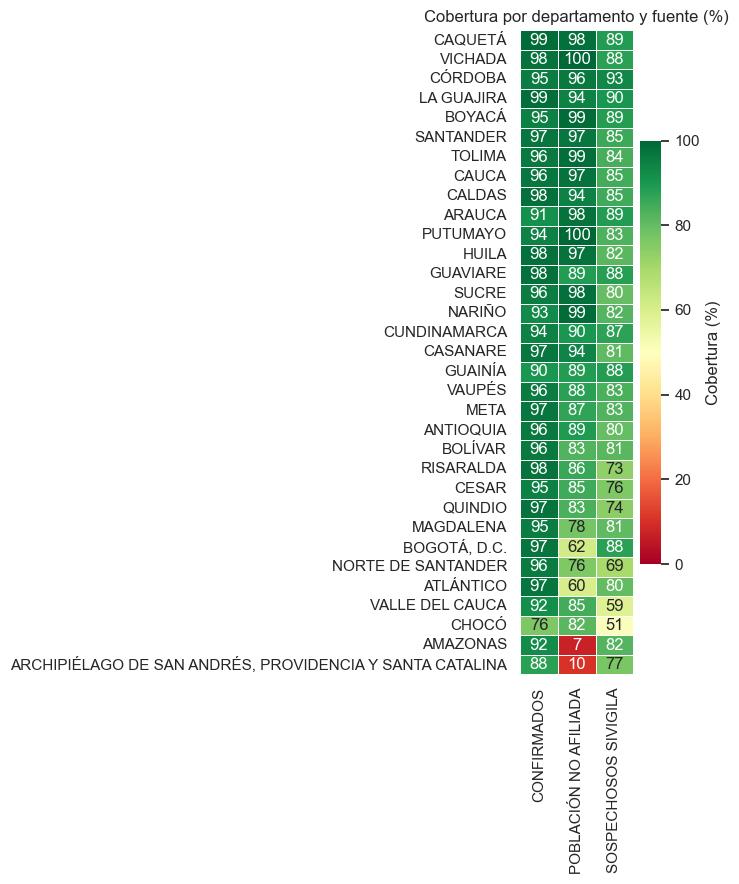

In [39]:
cruce = utils.cobertura_ponderada(df_prep, ['DepartamentoNombre', 'Fuente'])
pivote = cruce.pivot(index='DepartamentoNombre', columns='Fuente', values='CoberturaPct')
pivote = pivote.loc[pivote.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(pivote, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cobertura (%)'})
ax.set_title('Cobertura por departamento y fuente (%)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

El cruce revela un patrón consistente: dentro de cada departamento, los casos `CONFIRMADOS` presentan cobertura alta, mientras que `POBLACIÓN NO AFILIADA` y `SOSPECHOSOS SIVIGILA` concentran las mayores brechas, con fuerte variación territorial. Las celdas vacías indican departamentos sin registros de esa fuente. Así, las brechas no dependen solo del territorio ni solo de la fuente, sino de su interacción.

## Bloque 6 — Análisis temporal y síntesis

Se examina la evolución mensual del volumen de casos y de la cobertura de seguimiento, usando la fecha de registro ya tipada. Se agrega por mes para suavizar el ruido semanal.

### 32. Evolución mensual de casos y cobertura

El volumen de casos refleja las olas epidémicas; la cobertura mensual (ponderada por casos) muestra si el seguimiento se sostuvo durante los picos de demanda.

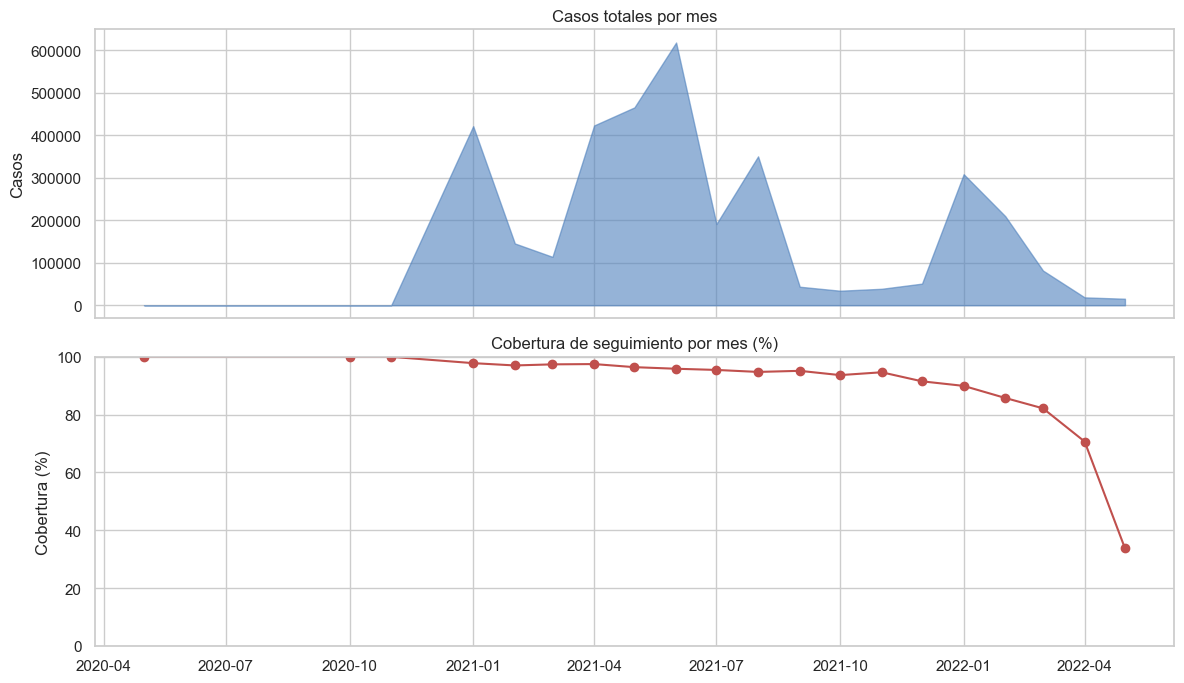

In [40]:
serie = df_prep.copy()
serie['Mes'] = serie['FechaRegistro'].dt.to_period('M').dt.to_timestamp()
serie = serie.groupby('Mes').agg(casos=('NumeroCasos', 'sum'),
                                 con=('NumeroCasosConSeguimiento', 'sum'))
serie['CoberturaPct'] = (serie['con'] / serie['casos'] * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(serie.index, serie['casos'], color='#4f81bd', alpha=0.6)
axes[0].set_title('Casos totales por mes')
axes[0].set_ylabel('Casos')
axes[1].plot(serie.index, serie['CoberturaPct'], marker='o', color='#c0504d')
axes[1].set_title('Cobertura de seguimiento por mes (%)')
axes[1].set_ylabel('Cobertura (%)')
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

El volumen de casos dibuja las olas epidémicas del periodo (mediados de 2020 a mayo de 2022). La cobertura mensual se mantiene alta y relativamente estable, lo que indica que el seguimiento se sostuvo incluso durante los picos; las caídas puntuales señalan los momentos de mayor presión sobre el sistema.

### 33. Síntesis del análisis exploratorio

Principales hallazgos:

- **Cobertura global del 94,4 %** (ponderada por casos), superior al promedio simple por fila (92,0 %): los grupos grandes tienen mejor cobertura.
- **Brecha por fuente:** `CONFIRMADOS` 96,0 %, frente a `SOSPECHOSOS SIVIGILA` 79,9 % y `POBLACIÓN NO AFILIADA` 75,5 %. El origen del registro es el factor más discriminante.
- **Heterogeneidad territorial y por entidad:** la cobertura varía por departamento y entre entidades de volumen comparable; las brechas surgen de la interacción territorio–fuente.
- **Distribución asimétrica:** la mayoría de los grupos son pequeños y la cobertura satura en 100 %; los atípicos reflejan el fenómeno, no errores.
- **Correlaciones lineales débiles** con el objetivo (la relación es no lineal por la saturación de la cobertura).
- **Estabilidad temporal:** el seguimiento se sostuvo a lo largo de las olas epidémicas.

Estos resultados orientan la siguiente etapa (modelado): la cobertura depende sobre todo de la fuente y del territorio/entidad, con una relación no lineal frente al tamaño del grupo.

## Bloque 7 — ¿La dispersión de la cobertura es ruido o estructura?

El diagrama de dispersión (sección 30) sugiere que la cobertura varía mucho entre grupos. Antes de **afirmar** que hay alta dispersión conviene investigar **por qué**: si esa variación respondiera a grupos bien diferenciados, no sería ruido sino **estructura**. El razonamiento es:

1. **Agrupar sin supervisión** (K-Means) los grupos según su perfil.
2. **Predecir el conglomerado** con un árbol de decisión, para medir *cuán diferenciados* están y *por cuáles características* se separan.
3. **Concluir:** si los grupos quedan muy diferenciados (el árbol los predice con alta exactitud), hay **variabilidad estructural** y se explica su causa; si fuesen indistinguibles, la dispersión sería ruido.

### 34. Agrupamiento de la cobertura (K-Means)

Se agrupan los grupos (filas) según su perfil: la cobertura de seguimiento, el tamaño en escala logarítmica `log1p(NumeroCasos)` —que normaliza la fuerte asimetría de los conteos (sección 20)— y la `Fuente`, codificada como indicadoras. Las variables se **estandarizan** (media 0, desviación 1) para que ninguna domine la distancia por su escala.

In [41]:
feats = utils.features_grupo(df_prep)
X_clu = utils.escalar(feats)
seleccion_k = utils.seleccionar_k(X_clu, k_min=2, k_max=7)
seleccion_k

,k,inercia,silueta
0,2,1.005562e+06,0.635479
1,3,6.657940e+05,0.682521
2,4,4.317717e+05,0.717068
3,5,2.313428e+05,0.702578
4,6,1.737669e+05,0.716192
5,7,1.233385e+05,0.689134


La silueta crece hasta `k = 4` (≈0.72) y a partir de ahí se **estabiliza** (apenas varía para k mayores), mientras la inercia dibuja su codo en torno al mismo valor. Por **parsimonia e interpretabilidad** se fijan **cuatro conglomerados**.

eta^2 cobertura entre conglomerados: 0.886
eta^2 tamano (log_casos) entre conglomerados: 0.006


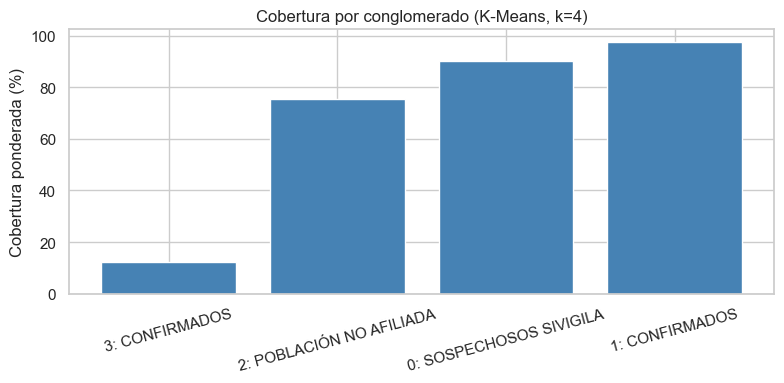

,n_filas,casos,fuente_domina,log_casos_medio,cobertura_simple,cobertura_ponderada,pct_filas,pct_casos
cluster,,,,,,,,
3,25164,95861,CONFIRMADOS,1.10,8.56,12.44,7.4,2.7
2,6729,38311,POBLACIÓN NO AFILIADA,1.15,86.28,75.45,2.0,1.1
0,26167,266954,SOSPECHOSOS SIVIGILA,1.40,95.88,90.17,7.7,7.6
1,281586,3131227,CONFIRMADOS,1.35,99.17,97.49,82.9,88.6


In [42]:
km = utils.ajustar_kmeans(X_clu, k=4)
caracter = utils.caracterizar_clusters(df_prep, feats, km.labels_)
eta2_cob = utils.eta2_entre_clusters(feats, km.labels_, 'cobertura_pct')
eta2_tam = utils.eta2_entre_clusters(feats, km.labels_, 'log_casos')
print(f'eta^2 cobertura entre conglomerados: {eta2_cob:.3f}')
print(f'eta^2 tamano (log_casos) entre conglomerados: {eta2_tam:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
etiquetas = [f'{i}: {f}' for i, f in zip(caracter.index, caracter['fuente_domina'])]
ax.bar(etiquetas, caracter['cobertura_ponderada'], color='steelblue')
ax.set_ylabel('Cobertura ponderada (%)')
ax.set_title('Cobertura por conglomerado (K-Means, k=4)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
caracter

La caracterización describe el perfil de cada conglomerado. Aparecen **cuatro regímenes** de cobertura muy distintos:

- **Régimen dominante (CONFIRMADOS):** 88,6 % de los casos con cobertura ponderada del **97,5 %** (el "todo seguido" que satura la distribución en 100 %, sección 21).
- **Brecha dura (CONFIRMADOS):** cobertura de apenas **12,4 %** pese a tratarse de casos confirmados (7,4 % de las filas).
- **SOSPECHOSOS SIVIGILA:** cobertura intermedia-alta (**90,2 %**).
- **POBLACIÓN NO AFILIADA:** la fuente de menor cobertura (**75,5 %**).

El `eta²` de la cobertura entre conglomerados es **0,886** (los grupos explican el 88,6 % de su varianza) y el del tamaño es casi nulo (**0,006**): los grupos se separan por cobertura y fuente, no por tamaño. Para confirmar que esta diferenciación es real —y leer **por cuáles características** se forma— se predice el conglomerado con un árbol de decisión.

Exactitud del arbol  ->  train: 0.9993  |  test: 0.9992

Importancia de las caracteristicas (por cuales se agrupo cada cluster):
fuente_SOSPECHOSOS SIVIGILA     0.436
cobertura_pct                   0.435
fuente_POBLACIÓN NO AFILIADA    0.129
log_casos                       0.000

Reglas que definen cada conglomerado:
|--- fuente_SOSPECHOSOS SIVIGILA <= 0.50
|   |--- cobertura_pct <= 50.05
|   |   |--- fuente_POBLACIÓN NO AFILIADA <= 0.50
|   |   |   |--- class: 3
|   |   |--- fuente_POBLACIÓN NO AFILIADA >  0.50
|   |   |   |--- class: 2
|   |--- cobertura_pct >  50.05
|   |   |--- fuente_POBLACIÓN NO AFILIADA <= 0.50
|   |   |   |--- class: 1
|   |   |--- fuente_POBLACIÓN NO AFILIADA >  0.50
|   |   |   |--- class: 2
|--- fuente_SOSPECHOSOS SIVIGILA >  0.50
|   |--- cobertura_pct <= 26.02
|   |   |--- cobertura_pct <= 20.27
|   |   |   |--- class: 3
|   |   |--- cobertura_pct >  20.27
|   |   |   |--- class: 3
|   |--- cobertura_pct >  26.02
|   |   |--- class: 0



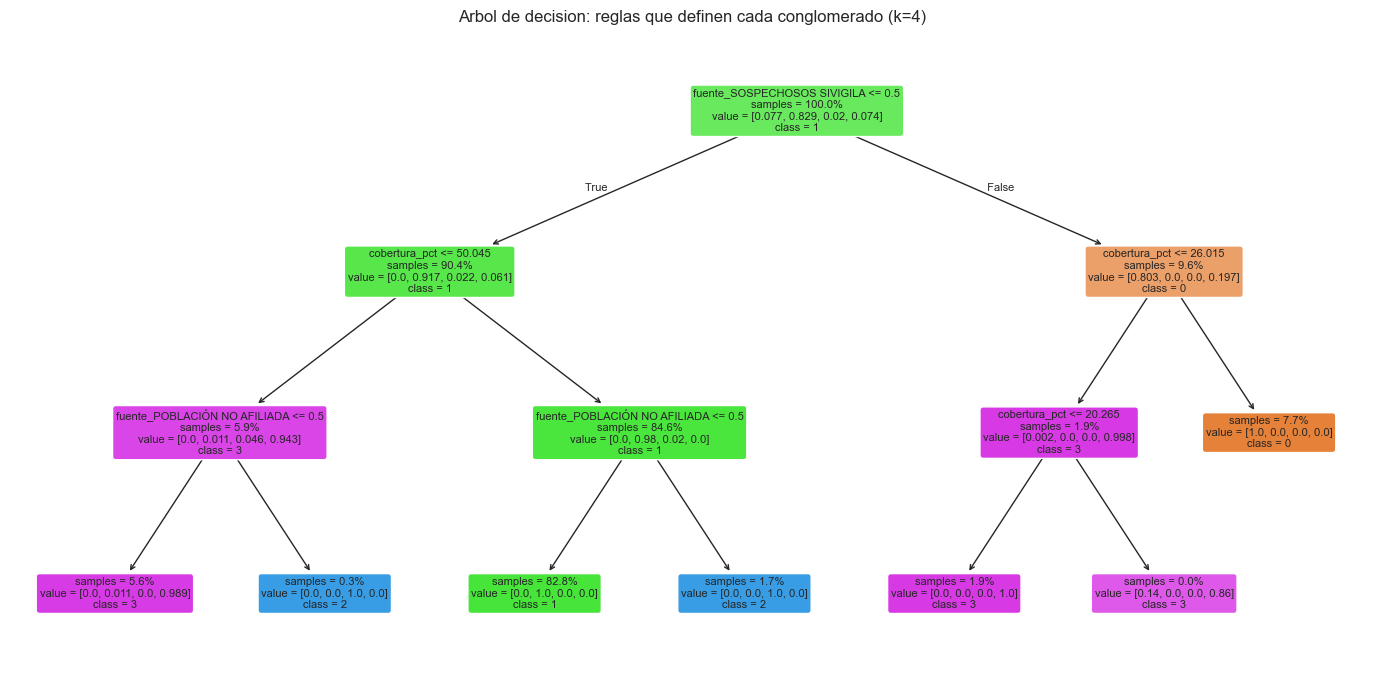

In [43]:
arbol, info = utils.arbol_clusters(feats, km.labels_, max_depth=3)
print(f"Exactitud del arbol  ->  train: {info['exactitud_train']:.4f}  |  test: {info['exactitud_test']:.4f}")
print('\nImportancia de las caracteristicas (por cuales se agrupo cada cluster):')
print(info['importancias'].round(3).to_string())
print('\nReglas que definen cada conglomerado:')
print(utils.reglas_arbol(arbol, feats.columns))

from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(14, 7))
clases = [str(c) for c in sorted(set(km.labels_))]
plot_tree(arbol, feature_names=list(feats.columns), class_names=clases,
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title('Arbol de decision: reglas que definen cada conglomerado (k=4)')
plt.tight_layout(); plt.show()


**Por cuáles características se agrupó cada conglomerado.** El árbol predice el grupo con **exactitud ≈ 0,999** (entrenamiento y prueba), de modo que los conglomerados están **netamente diferenciados**: no se confunden entre sí. Las características que los separan son la **`Fuente`** (importancia ≈ 0,56 sumando sus indicadoras) y la **cobertura** (≈ 0,44); el **tamaño del grupo no aporta nada** (importancia 0,000), lo que descarta que la agrupación sea un artefacto del volumen. Las reglas lo hacen explícito: por ejemplo, los *casos no sospechosos, con cobertura ≤ 50 % y que no son de población no afiliada* forman el bloque de **brecha dura**, mientras que los *no sospechosos con cobertura > 50 %* forman el **régimen dominante**.

**Conclusión: la dispersión es estructural, no ruido.** Como los grupos son muy distintos y separables (exactitud ≈ 0,999), la variación de la cobertura **sí** responde a una estructura. Su **causa** es el **origen del caso** (`Fuente`) combinado con el **régimen de cobertura**: coexisten un bloque mayoritario casi totalmente seguido (≈ 97,5 %) y un bloque de brecha dura (≈ 12,4 %), con las demás fuentes en niveles intermedios. El tamaño del grupo no interviene en la separación. Esta variabilidad estructural es la que justifica pasar a un **modelo** que la explique (Parte IV) en lugar de limitarse a describir un promedio.

### 35. Peso de las variables antes del modelo

Para anticipar qué predictores aportarán más —sin haber ajustado aún el modelo conjunto— se mide el **peso marginal** de cada variable: se ajusta un GLM binomial de **un solo factor** por predictor y se reporta la fracción de **devianza** del modelo nulo que explica por sí solo (`1 − devianza/devianza_nula`). Se acompaña de los **grados de libertad** (gl), porque un predictor con más niveles puede explicar más devianza por su mayor flexibilidad, no por ser más informativo.

In [44]:
peso = utils.peso_devianza_predictores(df_prep)
peso

,predictor,gl,devianza_explicada
0,EntidadRegistro,67,0.356987
1,Fuente,2,0.120879
2,DepartamentoNombre,32,0.049620
3,FechaRegistroSemana,1,0.003399


Lectura del peso de cada variable:

- **`Fuente` es el predictor más eficiente:** con solo **2 gl** explica el **12,1 %** de la devianza. Es mucho poder por grado de libertad y confirma que el origen del caso es el factor más discriminante (coherente con la sección 25 y con el agrupamiento anterior).
- **`EntidadRegistro`** explica la mayor devianza en bruto (**35,7 %**), pero con **67 gl**: buena parte de ese poder proviene de su alta cardinalidad; aporta información de gestión a costa de muchos parámetros.
- **`DepartamentoNombre`** aporta de forma moderada (**5,0 %**, 32 gl): existe heterogeneidad territorial real, pero menor que la de fuente o entidad.
- **`FechaRegistroSemana`** es prácticamente nula (**0,3 %**): el tiempo no explica la cobertura (coherente con la sección 32); se conserva solo como control.

Esto fundamenta la selección de predictores del modelo: el GLM debe apoyarse sobre todo en `Fuente`, `EntidadRegistro` y `DepartamentoNombre`, y tratar la semana como variable de control marginal.

# Parte IV — Modelado: cobertura de seguimiento

Se va a usar el dataset depurado `df_prep`

#### "Pre - teoria"

La sección siguiente formaliza el modelo con notación matemática. Antes conviene fijar la intuición, sin fórmulas.

**Qué queremos predecir.** No intentamos adivinar directamente el porcentaje de cobertura de un grupo (que casi siempre es 100 %, lo que complica todo), sino la **probabilidad de que un caso cualquiera reciba seguimiento**. Pensemos en cada caso como el lanzamiento de una moneda cargada: tiene una probabilidad `p` de salir "seguido". Esa `p` es lo que el modelo estima.

**Cómo la estima.** El modelo aprende cómo cambia esa probabilidad según las características del grupo: la fuente del caso, el departamento y la entidad. Por ejemplo, descubre que si el caso es "sospechoso" su probabilidad de seguimiento baja, y que según el departamento sube o baja.

**Por qué una probabilidad y no un número cualquiera.** Una probabilidad siempre vive entre 0 y 1 (entre 0 % y 100 %). El modelo usa una curva en forma de "S" (la función logística) que **nunca se sale de ese rango**: así jamás predice un imposible como 120 % o −5 %, problema que sí tendría una recta común.

**Cómo se lee el resultado: el "odds ratio".** Es solo una forma de comparar probabilidades; dice "cuántas veces más (o menos) probable". Un odds ratio de 0.09 para los casos sospechosos significa que, frente a un caso confirmado, sus posibilidades de recibir seguimiento son alrededor de **once veces menores**. Un valor cercano a 1 significa que "no cambia nada".

**Una última idea.** Los grupos con más casos aportan más información y por eso **pesan más** en el ajuste, igual que una encuesta con más respuestas resulta más confiable.

Con esta intuición en mente, la siguiente sección presenta la formulación formal.

### 36. Marco teórico: GLM binomial (regresión logística agregada)

Cada fila agrupa `NumeroCasos = N` casos, de los cuales `NumeroCasosConSeguimiento = k` recibieron seguimiento. El proceso generador natural es **binomial**: `k_i ~ Binomial(N_i, p_i)`, donde `p_i` es la probabilidad de que un caso del grupo `i` sea seguido. Un **modelo lineal generalizado (GLM)** con familia binomial y **enlace logit** modela esa probabilidad como

`logit(p_i) = ln( p_i / (1 - p_i) ) = b0 + b1 x_i1 + ... + bp x_ip`.

El enlace logit garantiza `p_i` en `(0, 1)` para cualquier valor de los predictores. Los coeficientes se estiman por **máxima verosimilitud** (algoritmo IRLS). Cada coeficiente `bj`, al exponenciarlo, se interpreta como un **odds ratio**: `exp(bj)` es el factor por el que se multiplican las probabilidades a favor del seguimiento (odds) ante un cambio unitario en `x_j`, manteniendo el resto constante. El supuesto binomial fija la varianza en `N p (1 - p)`; si la varianza observada lo excede, hay **sobredispersión**, que se diagnostica con el estadístico de dispersión (chi-cuadrado de Pearson sobre los grados de libertad).

### 37. Justificación: por qué este modelo para nuestra base

La Parte III mostró que la variable objetivo no admite los modelos habituales: la cobertura **satura en 100 %** (distribución inflada, no continua suave), por lo que una regresión lineal predeciría fuera de `[0, 100]` y una regresión Beta clásica es inaplicable (no admite 0 ni 1 exactos). El GLM binomial **esquiva ese problema** porque no modela el porcentaje sino la probabilidad de seguimiento por caso: la saturación se traduce en `p` cercana a 1, siempre dentro de rango.

Además, encaja con lo observado:
- **Pondera por el tamaño del grupo** de forma natural (la verosimilitud binomial pesa cada grupo por `N`), lo que corrige la heterocedasticidad (En términos sencillos, el modelo comete errores pequeños en algunas zonas, pero errores mucho más grandes en otras) de los scatterplots (sección 30): los grupos pequeños, ruidosos, influyen menos.
- Los **predictores** provienen del EDA: `Fuente` (el factor más discriminante, sección 25), `DepartamentoNombre` (heterogeneidad territorial, sección 26) y `EntidadRegistro` (diferencias de gestión, sección 27). Se añade `FechaRegistroSemana` para contrastar la ausencia de tendencia temporal (sección 32).
- Se **excluye `Municipio`** por su cardinalidad (1.121 niveles); el territorio queda representado por el departamento.

La respuesta se construye como la pareja `(k, N - k)`, que statsmodels trata como binomial agrupado.

### 38. Elección de la familia exponencial: ¿por qué la binomial?

Un GLM se especifica con tres piezas: una distribución de la **familia exponencial** para la respuesta, un **predictor lineal** y una **función de enlace**. La familia no se elige por gusto: la fijan el **soporte** de la respuesta (qué valores puede tomar) y su **relación media–varianza**. Aquí la respuesta es, por grupo, el número de casos seguidos `k` sobre un total `N`: un **conteo acotado de éxitos sobre ensayos**, ni continuo ni un conteo sin tope. La tabla contrasta las familias candidatas frente a ese dato.

| Familia | Soporte de la respuesta | Relación media–varianza | ¿Adecuada aquí? |
|---|---|---|---|
| Normal (Gaussiana) | Real continuo, (−∞, ∞) | Varianza constante | **No.** La cobertura está acotada en [0, 100] y es heterocedástica (la varianza cae al crecer `N`, sección 30); OLS predeciría valores imposibles fuera de rango. |
| Gamma / Inversa gaussiana | Real positivo continuo | Var ∝ media² | **No.** Sirve para magnitudes positivas continuas (tiempos, montos), no para una proporción acotada en 1. |
| Poisson | Enteros 0, 1, 2, … sin cota superior | Var = media | **No.** Modela conteos sin techo; aquí `k` está acotado por `N` y el interés es la proporción `k/N`, no el conteo. |
| **Binomial** | Enteros 0 … N (éxitos sobre `N` ensayos) | **Var = N·p·(1 − p)** | **Sí.** Es la distribución exacta de `k` éxitos en `N` ensayos Bernoulli: cada caso se sigue o no. Soporte correcto y varianza que decrece cuando `p → 1`, justo la menor dispersión de los grupos grandes (sección 30). |

**Por qué un GLM y no una regresión lineal.** La respuesta es discreta y acotada, con varianza que depende de la media; un modelo lineal gaussiano violaría sus tres supuestos (normalidad, homocedasticidad y soporte no acotado). El GLM generaliza la regresión: conserva un predictor lineal pero permite una familia adecuada al dato y un enlace que mantiene la predicción dentro del rango válido.

**Por qué, dentro de la familia, la binomial.** Es la única cuyo **proceso generador coincide con el dato**: `k ~ Binomial(N, p)`. Su relación media–varianza `N·p·(1 − p)` **pondera por `N`** de forma automática —corrigiendo la heterocedasticidad de la sección 30— y reproduce la saturación en 100 % como una varianza que colapsa cuando `p → 1`. Su **enlace canónico es el logit**, que transforma `p ∈ (0, 1)` en toda la recta real y garantiza que la probabilidad estimada nunca se salga de rango. El riesgo a vigilar es la **sobredispersión** (que la varianza real supere `N·p·(1 − p)` por heterogeneidad entre grupos); se diagnostica con el estadístico de dispersión y, de aparecer, se corrige con quasi-binomial o beta-binomial (sección 45).

### 39. Preparación de la matriz de modelado

Se construye la matriz de diseño (dummies de las categóricas más la semana) y la respuesta binomial mediante `utils.construir_diseno_glm`, y se separa un 20 % de prueba para evaluar la capacidad predictiva.

In [45]:
from sklearn.model_selection import train_test_split

df_modelo = df_prep
X, y = utils.construir_diseno_glm(df_modelo)

idx = np.arange(len(df_modelo))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=0)
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
y_tr = y[idx_tr]

print(f'Diseno: {X.shape[1]} columnas (incluye intercepto)')
print(f'Entrenamiento: {len(idx_tr):,} filas | Prueba: {len(idx_te):,} filas')

Diseno: 103 columnas (incluye intercepto)
Entrenamiento: 271,716 filas | Prueba: 67,930 filas


### 40. Ajuste del GLM binomial y bondad de ajuste

Se ajusta el modelo sobre el conjunto de entrenamiento y se reportan dos diagnósticos: el pseudo-R2 por devianza (proporción de devianza nula explicada) y el estadístico de dispersión.

In [46]:
res = utils.ajustar_glm_binomial(X_tr, y_tr)

print(f'Parametros estimados: {len(res.params)}')
print(f'Pseudo-R2 (devianza):        {utils.pseudo_r2_deviance(res):.4f}')
print(f'Estadistico de dispersion:   {utils.estadistico_dispersion(res):.3f}')

Parametros estimados: 103
Pseudo-R2 (devianza):        0.5136
Estadistico de dispersion:   2.768


El **pseudo-R2 por devianza (≈0.51)** indica que los predictores explican alrededor de la mitad de la devianza del modelo nulo: un ajuste considerable para un fenómeno con fuerte componente idiosincrásico. El **estadístico de dispersión (≈2.8)**, muy por encima de 1, revela **sobredispersión**: la variabilidad entre grupos supera la que predice el modelo binomial. Esto no invalida las estimaciones puntuales, pero **subestima los errores estándar**; se retoma en la sección 45.

### 41. Interpretación: odds ratios por fuente

Se exponen los odds ratios de la `Fuente` (referencia: `CONFIRMADOS`, categoría omitida) y de la semana. Un odds ratio menor que 1 indica menor probabilidad de seguimiento frente a la referencia.

In [47]:
or_tab = utils.tabla_odds_ratios(res)
sel = [t for t in or_tab.index if str(t).startswith('Fuente') or t == 'FechaRegistroSemana']
or_tab.loc[sel].round(4)

,odds_ratio,ic_2.5%,ic_97.5%,p_valor
Fuente_SOSPECHOSOS SIVIGILA,0.0878,0.0864,0.0892,0.0
FechaRegistroSemana,0.9867,0.9862,0.9872,0.0
Fuente_POBLACIÓN NO AFILIADA,21.3348,17.3023,26.3072,0.0


Tomando `CONFIRMADOS` como referencia, los casos `SOSPECHOSOS SIVIGILA` presentan un **odds ratio ≈ 0.09**: sus odds de seguimiento son cerca de **once veces menores**, consistente con la brecha del EDA. El término `FechaRegistroSemana` tiene un OR cercano a 1 (sin efecto temporal apreciable), como anticipaba la sección 32.

Un matiz relevante: `POBLACIÓN NO AFILIADA`, que en el análisis **marginal** tenía la cobertura más baja (sección 33), aquí muestra un OR **ajustado mayor que 1**. La aparente contradicción es un caso de **confusión (paradoja de Simpson)**: esos casos se concentran en territorios y entidades de baja cobertura; una vez que el modelo controla por departamento y entidad, dentro de un mismo estrato la condición de no afiliado deja de asociarse a menor seguimiento. Es un hallazgo que el análisis bivariado no podía revelar.

### 42. Heterogeneidad territorial: odds ratios por departamento

Se ordenan los departamentos por su odds ratio respecto a la categoría de referencia, para localizar las brechas ajustadas (controlando por fuente y entidad).

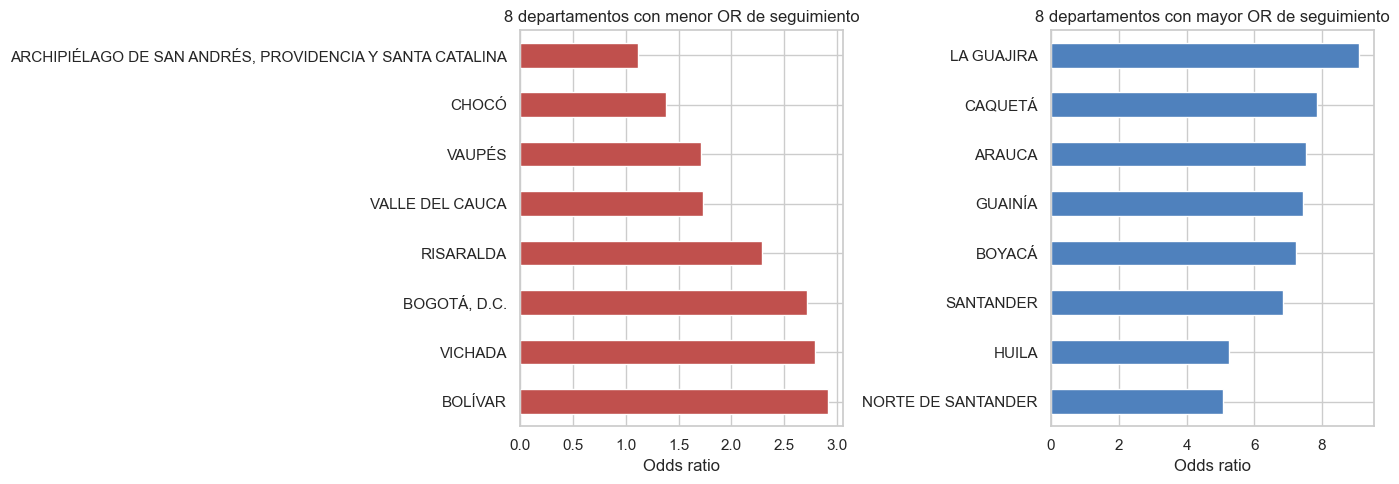

In [48]:
dep = or_tab[or_tab.index.str.startswith('DepartamentoNombre_')].copy()
dep.index = dep.index.str.replace('DepartamentoNombre_', '', regex=False)
dep = dep[np.isfinite(dep['odds_ratio'])].sort_values('odds_ratio')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dep.head(8)['odds_ratio'].plot.barh(ax=axes[0], color='#c0504d')
axes[0].set_title('8 departamentos con menor OR de seguimiento')
axes[0].set_xlabel('Odds ratio')
axes[0].invert_yaxis()
dep.tail(8)['odds_ratio'].plot.barh(ax=axes[1], color='#4f81bd')
axes[1].set_title('8 departamentos con mayor OR de seguimiento')
axes[1].set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

Los departamentos del extremo inferior concentran las mayores brechas ajustadas, coherente con la sección 26. Conviene advertir una limitación: algunos niveles de baja frecuencia con cobertura de 0 % o 100 % producen **separación cuasi-completa**, que infla coeficientes e intervalos de confianza (sus valores no finitos se omiten del gráfico). Esta inestabilidad es consecuencia directa de la distribución saturada de la objetivo y motiva el uso de regularización o efectos aleatorios (sección 45).

### 43. Evaluación predictiva y calibración

Sobre el conjunto de prueba se calcula el **Brier score** (error cuadrático medio a nivel de caso) frente a un baseline trivial que asigna a todos la cobertura global, y se contrasta la cobertura observada con la predicha por departamento.

In [49]:
df_te = df_modelo.iloc[idx_te].copy()
df_te['p_pred'] = res.predict(X_te).to_numpy()

brier = utils.brier_ponderado(df_te, df_te['p_pred'].to_numpy())
base = df_modelo.iloc[idx_tr]['NumeroCasosConSeguimiento'].sum() / df_modelo.iloc[idx_tr]['NumeroCasos'].sum()
brier_base = utils.brier_ponderado(df_te, np.full(len(df_te), base))
print(f'Brier (modelo):   {brier:.5f}')
print(f'Brier (baseline): {brier_base:.5f}')

cal_fuente = df_te.groupby('Fuente', observed=True).apply(
    lambda d: pd.Series({
        'obs_%': d['NumeroCasosConSeguimiento'].sum() / d['NumeroCasos'].sum() * 100,
        'pred_%': (d['p_pred'] * d['NumeroCasos']).sum() / d['NumeroCasos'].sum() * 100,
    })
).round(2)
cal_fuente

Brier (modelo):   0.04249
Brier (baseline): 0.05476


,obs_%,pred_%
Fuente,,
CONFIRMADOS,96.04,96.02
POBLACIÓN NO AFILIADA,78.99,74.23
SOSPECHOSOS SIVIGILA,78.85,78.43


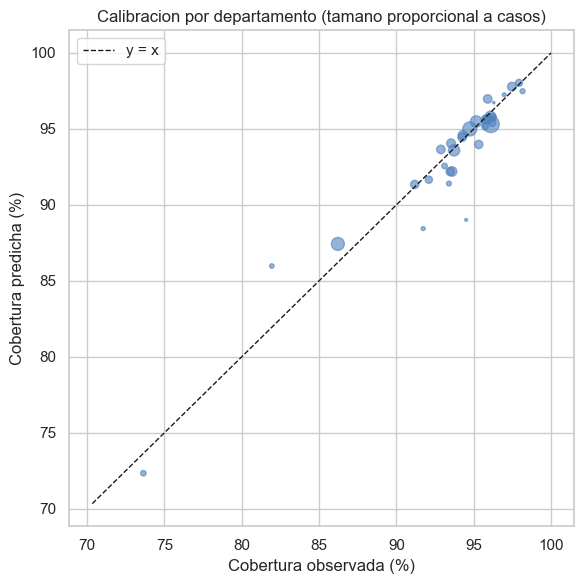

In [50]:
cal_dep = df_te.groupby('DepartamentoNombre', observed=True).apply(
    lambda d: pd.Series({
        'obs': d['NumeroCasosConSeguimiento'].sum() / d['NumeroCasos'].sum() * 100,
        'pred': (d['p_pred'] * d['NumeroCasos']).sum() / d['NumeroCasos'].sum() * 100,
        'casos': d['NumeroCasos'].sum(),
    })
).reset_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cal_dep['obs'], cal_dep['pred'], s=np.sqrt(cal_dep['casos']) / 3,
           alpha=0.6, color='#4f81bd')
lo = min(cal_dep['obs'].min(), cal_dep['pred'].min()) - 2
ax.plot([lo, 100], [lo, 100], 'k--', lw=1, label='y = x')
ax.set_xlabel('Cobertura observada (%)')
ax.set_ylabel('Cobertura predicha (%)')
ax.set_title('Calibracion por departamento (tamano proporcional a casos)')
ax.legend()
plt.tight_layout()
plt.show()

El **Brier score del modelo (≈0.042)** mejora frente al del baseline (**≈0.055**), una reducción cercana al 22 %. La calibración por fuente y por departamento es buena: los puntos se alinean con la diagonal `y = x`, sin sesgos sistemáticos relevantes. El modelo, por tanto, no solo es interpretable sino que **predice de forma calibrada** la cobertura a nivel de grupo.

### 44. Clasificación de casos: matriz de confusión y métricas

El GLM produce una **probabilidad** de seguimiento por grupo, no una etiqueta. Para construir una matriz de confusión se lleva la evaluación a **nivel de caso** (cada uno de los `NumeroCasos` es un ensayo seguido/no seguido) y se umbraliza la probabilidad predicha sobre el conjunto de prueba. Como la clase está muy desbalanceada (la mayoría de los casos sí reciben seguimiento), se reporta el **AUC-ROC** —que no depende del umbral— como medida principal, y se contrasta el umbral estándar de 0.5 con uno orientado a detectar la brecha.

In [51]:
from sklearn.metrics import roc_curve

y_caso, score_caso, peso_caso = utils.expandir_a_casos(df_te, df_te['p_pred'].to_numpy())
fpr, tpr, thr = roc_curve(y_caso, score_caso, sample_weight=peso_caso)
u_opt = float(thr[np.argmax(tpr - fpr)])

met = utils.metricas_clasificacion(y_caso, score_caso, peso_caso, umbral=0.5)
print('Metricas (umbral 0.5):')
for k, v in met.items():
    print(f'  {k:24s}: {v:.4f}')

utils.matriz_confusion_casos(y_caso, score_caso, peso_caso, umbral=0.5)

Metricas (umbral 0.5):
  umbral                  : 0.5000
  accuracy                : 0.9481
  sensibilidad_seguido    : 0.9935
  especificidad_noseguido : 0.2118
  precision_seguido       : 0.9533
  f1_seguido              : 0.9730
  auc_roc                 : 0.8776


,Pred: No seguido,Pred: Seguido
Real: No seguido,8314.0,30931.0
Real: Seguido,4111.0,631765.0


Al umbral estándar de 0.5 la **exactitud parece alta (≈0.95)**, pero es engañosa: la sensibilidad para la clase "seguido" es ≈0.99 mientras que la **especificidad —capacidad de detectar los casos sin seguimiento, que son la brecha de interés— es apenas ≈0.21**. Es el efecto directo del desbalance (cerca del 94 % de los casos sí se siguen): predecir "seguido" casi siempre acierta. La matriz lo confirma: la mayoría de los casos sin seguimiento caen en la columna "Pred: Seguido". Por eso la medida principal es el **AUC-ROC ≈ 0.88**, que no depende del umbral y muestra que el modelo sí discrimina bien entre casos seguidos y no seguidos.

In [52]:
umbrales = {'0.50': 0.5, '0.90': 0.9, f'Youden ({u_opt:.2f})': u_opt}
pd.DataFrame(
    {nombre: utils.metricas_clasificacion(y_caso, score_caso, peso_caso, u)
     for nombre, u in umbrales.items()}
).T.round(4)

,umbral,accuracy,sensibilidad_seguido,especificidad_noseguido,precision_seguido,f1_seguido,auc_roc
0.50,0.500,0.9481,0.9935,0.2118,0.9533,0.9730,0.8776
0.90,0.900,0.8717,0.8863,0.6345,0.9752,0.9286,0.8776
Youden (0.95),0.954,0.7212,0.7125,0.8633,0.9883,0.8280,0.8776


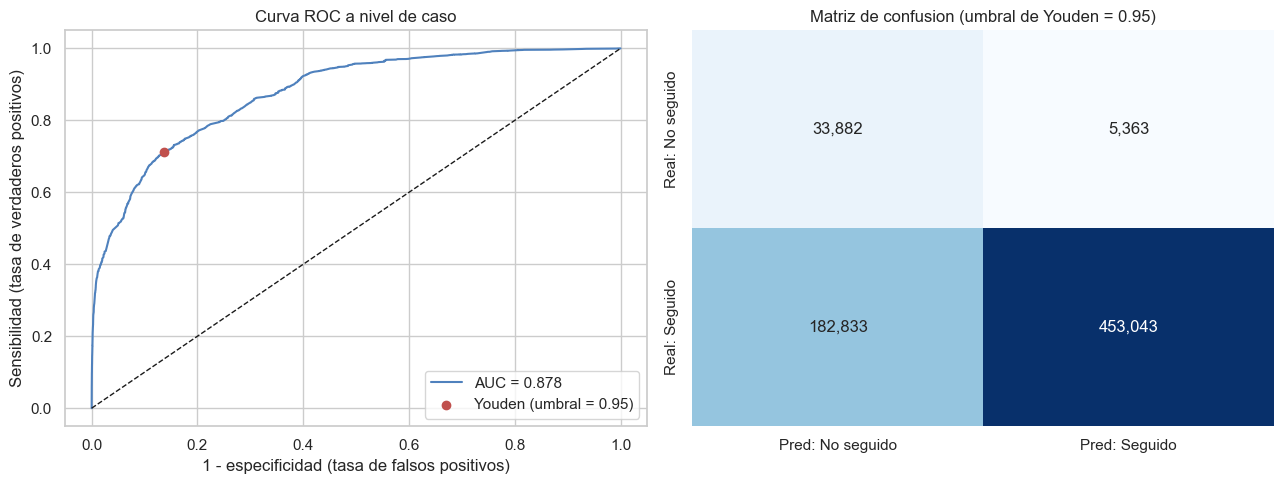

In [53]:
j = int(np.argmax(tpr - fpr))
cm_opt = utils.matriz_confusion_casos(y_caso, score_caso, peso_caso, umbral=u_opt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color='#4f81bd', label=f"AUC = {met['auc_roc']:.3f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].scatter(fpr[j], tpr[j], color='#c0504d', zorder=5,
                label=f'Youden (umbral = {u_opt:.2f})')
axes[0].set_xlabel('1 - especificidad (tasa de falsos positivos)')
axes[0].set_ylabel('Sensibilidad (tasa de verdaderos positivos)')
axes[0].set_title('Curva ROC a nivel de caso')
axes[0].legend(loc='lower right')
sns.heatmap(cm_opt, annot=True, fmt=',.0f', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title(f'Matriz de confusion (umbral de Youden = {u_opt:.2f})')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

El umbral funciona como una **palanca de decisión**. Subirlo de 0.5 al punto de **Youden (≈0.95)** eleva la especificidad de ≈0.21 a ≈0.86 —se detecta la gran mayoría de los casos sin seguimiento— a cambio de reducir la sensibilidad a ≈0.71 y aceptar más falsas alarmas. La elección depende del objetivo: para **priorizar territorios y entidades con brecha** conviene un umbral alto (más detección de la clase minoritaria). En conjunto, un **AUC de 0.88** confirma un poder de discriminación notable para datos administrativos agregados, coherente con la buena calibración de la sección 43.

### 45. Diagnóstico, limitaciones y modelos siguientes

El GLM binomial es un **modelo base sólido e interpretable**, pero el diagnóstico revela dos limitaciones que orientan la siguiente iteración:

1. **Sobredispersión** (dispersión ≈2.8): la varianza entre grupos excede la binomial, lo que subestima los errores estándar.
2. **Separación cuasi-completa** en niveles raros con cobertura 0/100 %, que desestabiliza algunos coeficientes.

Modelos propuestos para superarlas, en orden de afinidad con los hallazgos:

**(a) Modelo multinivel / GLMM logístico.** Trata `Departamento`, `Municipio` y `EntidadRegistro` como **efectos aleatorios**. El *shrinkage* estabiliza los niveles con pocos casos (mitiga la separación) y absorbe parte de la sobredispersión. Es el paso natural para la heterogeneidad territorio-entidad.

```python
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
# Esquema ilustrativo: intercepto aleatorio por departamento
# modelo_ml = BinomialBayesMixedGLM.from_formula(
#     'seguido ~ Fuente + FechaRegistroSemana',
#     vc_formulas={'dep': '0 + C(DepartamentoNombre)'}, data=...)
```

**(b) Regresión beta-binomial.** Generaliza la binomial con un parámetro de dispersión; modela explícitamente la sobredispersión detectada.

**(c) Zero-One-Inflated Beta (ZOIB).** Si se desea modelar el porcentaje directamente, es la única familia que respeta la masa puntual en 0 % y 100 % (típicamente bayesiana, con `pymc`).

**(d) Gradient boosting + SHAP.** Reformulando como clasificación de **brecha** (`cobertura < umbral`), `LightGBM`/`XGBoost` captura interacciones no lineales (territorio x fuente) sin supuestos distribucionales y es robusto a la separación; **SHAP** cuantifica la contribución de cada factor y produce una probabilidad de brecha accionable por grupo.

```python
import lightgbm as lgb
import shap
# y_brecha = (df_prep['CoberturaConSeguimiento'] < 100).astype(int)
# clf = lgb.LGBMClassifier(class_weight='balanced').fit(X, y_brecha)
# valores = shap.TreeExplainer(clf).shap_values(X)
```

### 46. Modelo redefinido a partir de los conglomerados: interacción Fuente × Departamento (quasi-binomial)

El análisis de conglomerados (sección 34) mostró que lo que diferencia a los grupos —y por tanto ayuda a predecir la cobertura— es la **fuente** del caso y la existencia de un **régimen de brecha dura**, que vive en la interacción entre fuente y territorio (la misma señal de la paradoja de Simpson de la sección 41). La etiqueta de conglomerado **no** puede usarse como predictor —se construyó con la cobertura, sería fuga de información—, pero sí puede **modelarse esa heterogeneidad**: se añade el término de interacción `Fuente × Departamento` y se ajusta el GLM como **quasi-binomial** para corregir la sobredispersión diagnosticada (sección 45).

La interacción se restringe a las celdas con soporte suficiente y **no saturadas** en 0 % o 100 %: las celdas saturadas quedan perfectamente separadas y producirían coeficientes divergentes (un eco de la saturación que motiva todo el proyecto).

In [54]:
Xint, yint = utils.construir_diseno_interaccion(df_modelo)
res_int = utils.ajustar_quasibinomial(Xint.iloc[idx_tr], yint[idx_tr])

p_base = res.predict(X.iloc[idx_te])
p_int = res_int.predict(Xint.iloc[idx_te])
comparacion = pd.DataFrame(
    {
        'columnas': [X.shape[1], Xint.shape[1]],
        'pseudo_R2': [utils.pseudo_r2_deviance(res), utils.pseudo_r2_deviance(res_int)],
        'dispersion': [utils.estadistico_dispersion(res), utils.estadistico_dispersion(res_int)],
        'Brier_test': [utils.brier_ponderado(df_te, p_base), utils.brier_ponderado(df_te, p_int)],
    },
    index=['Base', 'Redefinido (+ Fuente x Depto)'],
)
print(f'Escala quasi-binomial (dispersion de Pearson): {res_int.scale:.3f}  ->  SE inflados x{res_int.scale**0.5:.2f}')
comparacion.round(4)

Escala quasi-binomial (dispersion de Pearson): 2.940  ->  SE inflados x1.71


,columnas,pseudo_R2,dispersion,Brier_test
Base,103,0.5136,2.7682,0.0425
Redefinido (+ Fuente x Depto),148,0.5291,2.9396,0.0421


La interacción mejora el ajuste de forma **moderada** (pseudo-R2 0,514 → 0,529; Brier 0,0425 → 0,0421 en prueba), pero la **sobredispersión persiste** (≈2,8 → ≈2,9): no proviene de un término de interacción faltante, sino de **heterogeneidad intrínseca entre grupos**. La lectura es doble:

- El **quasi-binomial** fija la escala en la dispersión de Pearson, de modo que los errores estándar se inflan por su raíz (≈ ×1,7) y la inferencia deja de ser optimista; las estimaciones puntuales no cambian respecto al binomial.
- La mejora marginal de la interacción confirma que el camino estructural correcto es un **modelo jerárquico** (beta-binomial o GLMM con efectos aleatorios por departamento y entidad), que el propio clustering ya motivaba: capturaría por *shrinkage* la heterogeneidad residual sin la separación de las celdas saturadas.

### 47. Síntesis de la Parte IV

- Se ajustó un **GLM binomial (logístico agregado)** sobre la probabilidad de seguimiento por caso, modelo coherente con la naturaleza del dato y robusto a la saturación de la cobertura.
- **Bondad de ajuste:** pseudo-R2 por devianza ≈0.51 y mejora del Brier frente al baseline (≈0.042 vs ≈0.055), con calibración correcta por fuente y departamento.
- **Hallazgos:** la `Fuente` es el factor dominante (`SOSPECHOSOS` con odds unas once veces menores que `CONFIRMADOS`); el efecto **ajustado** de `POBLACIÓN NO AFILIADA` revela confusión con el territorio (paradoja de Simpson); sin efecto temporal.
- **Limitaciones:** sobredispersión (≈2.8) y separación cuasi-completa en niveles raros, que motivan los modelos multinivel, beta-binomial, ZOIB y de boosting esbozados como continuación.

### 48. Modelo jerárquico (explicativo, no predictivo): GLMM logístico de intercepto aleatorio por departamento

El diagnóstico de la sección 45 mostró que la sobredispersión (≈2.8) **persiste** y no proviene de una interacción omitida, sino de **heterogeneidad intrínseca entre grupos**. Se ajusta el paso jerárquico que el clustering ya motivaba: un GLMM logístico con **efecto fijo `Fuente`** (el factor dominante) e **intercepto aleatorio por `DepartamentoNombre`**. Así la variación territorial deja de contarse como sobredispersión y pasa a modelarse como un **componente de varianza**; el *shrinkage* estabiliza los departamentos con pocos casos.

El ajuste (`statsmodels`, aproximación de Laplace) exige respuesta binaria por caso, mientras el dato está agregado en conteos `(k, N)`. Por viabilidad se ajusta sobre una muestra de casos estratificada por celda `Departamento x Fuente`, generada con probabilidad `k/N` y tamaño proporcional a `N`.

In [ ]:
res_glmm = utils.ajustar_glmm_intercepto(df_modelo)

sd_terr = float(np.exp(res_glmm.vcp_mean[0]))
print(f'SD del intercepto aleatorio (territorio): {sd_terr:.3f}')
print('
Odds ratios de Fuente (ref. CONFIRMADOS):')
for nombre, coef in zip(res_glmm.model.fep_names[1:], res_glmm.fe_mean[1:]):
    print(f'  {nombre}: {np.exp(coef):.3f}')
res_glmm.summary()

La **desviación del intercepto aleatorio** (≈0.50 en escala logit, con intervalo que excluye valores próximos a cero) confirma una **heterogeneidad territorial sustantiva**: a igualdad de fuente, los departamentos difieren de forma sistemática en la probabilidad de seguimiento. Las **odds ratios de `Fuente`** (`POBLACIÓN NO AFILIADA` ≈0.12 y `SOSPECHOSOS SIVIGILA` ≈0.18) reproducen el patrón del GLM base, ahora con el territorio **absorbido** por el efecto aleatorio en lugar de inflar la sobredispersión.

El modelo jerárquico es así la representación adecuada de la dispersión estructural detectada en el clustering: no la elimina, la **explica** como variación entre grupos. Como extensión natural quedaría añadir `EntidadRegistro` como segundo efecto aleatorio y contrastar una beta-binomial.

### 49. Capacidad predictiva del GLMM frente al GLM (modelo explicativo)

Para contrastar la capacidad predictiva se ajusta el GLMM sobre el mismo conjunto de entrenamiento y se compara su Brier en prueba con el del GLM binomial base. Debe anticiparse que el GLM emplea más predictores como efectos fijos (`Fuente`, `Departamento`, `EntidadRegistro` y semana), mientras el GLMM usa solo `Fuente` fija y el territorio como efecto aleatorio.

In [ ]:
res_glmm_tr = utils.ajustar_glmm_intercepto(df_modelo.iloc[idx_tr])
p_glmm = utils.predecir_glmm_intercepto(res_glmm_tr, df_te)
p_glm = res.predict(X_te)

print(f'Brier en prueba  GLM binomial : {utils.brier_ponderado(df_te, p_glm):.4f}')
print(f'Brier en prueba  GLMM         : {utils.brier_ponderado(df_te, p_glmm):.4f}')

El GLMM **no mejora el Brier** (≈0.051 frente a ≈0.043 del GLM): no es un modelo más preciso, y no debe esperarse que lo sea. Dos razones: (i) usa menos predictores —solo `Fuente` y el territorio aleatorio, sin `EntidadRegistro` ni semana—; (ii) el *shrinkage* acerca deliberadamente las estimaciones de cada departamento hacia la media global, sacrificando ajuste puntual a cambio de **estabilidad** en los niveles con pocos casos.

El valor del GLMM es, por tanto, **inferencial y explicativo**, no predictivo: cuantifica la heterogeneidad territorial (SD ≈0.50 en logit) y entrega errores estándar honestos, frente a un GLM que, siendo más preciso en conjunto, subestimaba la incertidumbre por la sobredispersión. Para predicción pura conviene el GLM (o el boosting esbozado en la sección 45); para **medir y explicar** la dispersión, el GLMM.

### 50. ¿Es bueno el GLM? Comparación predictiva con modelos de referencia

Para juzgar la calidad **predictiva** del GLM se contrasta su Brier en prueba con dos referencias más simples: un **modelo de referencia** que asigna a todos los grupos la cobertura global del entrenamiento, y un **modelo simple** que usa únicamente el factor dominante `Fuente`. Un Brier menor indica mejor predicción.

In [ ]:
p_ref = df_modelo.iloc[idx_tr]['NumeroCasosConSeguimiento'].sum() / df_modelo.iloc[idx_tr]['NumeroCasos'].sum()
brier_ref = utils.brier_ponderado(df_te, np.full(len(df_te), p_ref))

Xf, yf = utils.construir_diseno_glm(df_modelo, categoricas=('Fuente',), numericas=())
res_fuente = utils.ajustar_glm_binomial(Xf.iloc[idx_tr], yf[idx_tr])
brier_fuente = utils.brier_ponderado(df_te, res_fuente.predict(Xf.iloc[idx_te]))

brier_glm = utils.brier_ponderado(df_te, res.predict(X_te))

print(f'Modelo de referencia (cobertura global): {brier_ref:.4f}')
print(f'Modelo simple (solo Fuente)            : {brier_fuente:.4f}')
print(f'GLM completo                           : {brier_glm:.4f}')

El GLM completo obtiene el menor Brier (≈0.043), por debajo del modelo simple de solo `Fuente` (≈0.052) y del modelo de referencia (≈0.055). Reduce el error cerca de un **22 % frente a la referencia** y supera al modelo de un solo factor.

La lectura es directa: incorporar el territorio, la entidad y la semana **aporta información predictiva real**, no es complejidad superflua. El GLM es, por tanto, un **buen modelo predictivo** para la cobertura de seguimiento.